# MVPA Distinctiveness Analysis
Port of 02_strippeddown.ipynb to sym_pt project.

**Changes from long_pt version:**
1. Paths point to sym_pt processed directory
2. Subject info from unified long-format CSV via sym_pt_params
3. Brain mask from ses-01 applied before thresholding (new)

**Everything else matches long_pt:** same COPE_MAP, same 6mm sphere, same z>2.3 threshold, same distinctiveness metric.

In [ ]:
# CELL 1: Setup & Configuration  (CLEANED)
###############################################################################
import os, sys
import numpy as np
import nibabel as nib
import pandas as pd
import pickle
from pathlib import Path
from scipy.ndimage import label, center_of_mass
from scipy.stats import pearsonr, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, is_patient,
                           get_sessions, get_sub_info, _load_csv)

BASE_DIR = Path(processed_dir)
OUTPUT_DIR = BASE_DIR / 'analyses' / 'mvpa_distinctiveness'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Contrast maps ---
# Differential contrasts — used for ROI definition (Cell 3)
COPE_MAP = {'face': 1, 'house': 2, 'object': 3, 'word': 12}

# RSA cope options — switchable via RSA_METHOD
RSA_COPE_MAP = {'face': 15, 'house': 16, 'object': 17, 'word': 18}       # raw category betas
CAT_VS_SCRAMBLE_MAP = {'face': 1, 'house': 2, 'object': 3, 'word': 12}   # differential contrasts

RSA_METHOD = 'raw'   # <<< SWITCH HERE: 'raw' or 'cat_vs_scramble'
ACTIVE_RSA_MAP = RSA_COPE_MAP if RSA_METHOD == 'raw' else CAT_VS_SCRAMBLE_MAP

# --- Category laterality ---
BILATERAL_CATEGORIES = ['object', 'house']
UNILATERAL_CATEGORIES = ['face', 'word']
PREFERRED_HEMI = {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

# --- Exclusions ---
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}
AGE_MATCH_DROP = ['sub-025', 'sub-027', 'sub-045', 'sub-072']
SUBJECTS_TO_SKIP = ['OTC108']

print(f'Base: {BASE_DIR}')
print(f'RSA method: {RSA_METHOD}')
print(f'Active RSA map: {ACTIVE_RSA_MAP}')
print(f'COPE_MAP (ROI def): {COPE_MAP}')
print(f'Pre-surgical exclusions: {len(PRE_SURGERY_SESSIONS)} subjects')
print('Setup complete.')

Base: /user_data/csimmon2/sym_pt
RSA method: raw
Active RSA map: {'face': 15, 'house': 16, 'object': 17, 'word': 18}
COPE_MAP (ROI def): {'face': 1, 'house': 2, 'object': 3, 'word': 12}
Pre-surgical exclusions: 8 subjects
Setup complete.


In [39]:
# CELL 2: Load Subjects
df = _load_csv()

def load_subjects(patient_only=None):
    """Load subjects from unified CSV. patient_only: True/False/None(all)"""
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sessions = get_sessions(sub_clean)
        if not sessions:
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)

        if patient_only is True and not pt:
            continue
        if patient_only is False and pt:
            continue

        # Check directory exists
        if not (BASE_DIR / f'sub-{sub_clean}').exists():
            continue

        intact = info.get('intact_hemi', '')
        if pt:
            hemi = 'l' if intact == 'left' else 'r'
        else:
            hemi = 'r'  # default for controls; left done separately

        subjects[f'sub-{sub_clean}'] = {
            'code': f"{info.get('group','')}{sub_clean}",
            'sessions': [f'{s:02d}' for s in sessions],
            'hemi': hemi,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact
        }
    return subjects

ALL_PATIENTS = load_subjects(patient_only=True)
ALL_CONTROLS = load_subjects(patient_only=False)
ANALYSIS_SUBJECTS = {**ALL_PATIENTS, **ALL_CONTROLS}

print(f'Loaded {len(ANALYSIS_SUBJECTS)} subjects')
print(f'  Patients: {len(ALL_PATIENTS)}, Controls: {len(ALL_CONTROLS)}')

# ============================================================================
# CELL 2 ADDITION: Add helper function after load_subjects
# ============================================================================

def get_post_surgery_sessions(subject_id, all_sessions):
    """Filter to only post-surgical sessions for a subject."""
    if subject_id in PRE_SURGERY_SESSIONS:
        pre_sessions = PRE_SURGERY_SESSIONS[subject_id]
        return [s for s in all_sessions if s not in pre_sessions]
    return all_sessions

def get_longitudinal_sessions(subject_id, all_sessions):
    """Get valid session pairs for longitudinal analysis (post-surgery only)."""
    post_sessions = get_post_surgery_sessions(subject_id, all_sessions)
    if len(post_sessions) >= 2:
        return post_sessions
    return []

print(f"\nLongitudinal eligibility:")
for sid, info in ANALYSIS_SUBJECTS.items():
    long_ses = get_longitudinal_sessions(sid, info['sessions'])
    if info['patient_status'] == 'patient' and len(long_ses) < 2:
        print(f"  {info['code']}: NO valid longitudinal data (post-surgery sessions: {get_post_surgery_sessions(sid, info['sessions'])})")


Loaded 50 subjects
  Patients: 26, Controls: 24

Longitudinal eligibility:
  nonOTC047: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC049: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC066: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC069: NO valid longitudinal data (post-surgery sessions: ['01'])
  nonOTC070: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC073: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC074: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC075: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC076: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC077: NO valid longitudinal data (post-surgery sessions: ['01'])
  OTC078: NO valid longitudinal data (post-surgery sessions: ['01'])
  nonOTC081: NO valid longitudinal data (post-surgery sessions: ['02'])
  nonOTC086: NO valid longitudinal data (post-surgery sessions: ['02'])
  OTC089: 

In [48]:
# CELL 2b: File Verification — Run AFTER Cell 2, BEFORE Cell 3
###############################################################################

def verify_files(analysis_subjects):
    """
    Check every file the pipeline will try to load:
      1. Brain mask (Cell 3): ses-{first}/anat/T1w_brain_mask.nii.gz
      2. Search masks (Cell 3): {hemi}_{category}_searchmask.nii.gz
      3. Zstat files (Cell 3): cope{N}.feat/stats/zstat1[_sesXX].nii.gz
      4. Beta/cope files (Cell 4): cope{N}.feat/stats/cope1[_sesXX].nii.gz
    """

    summary = {
        'brain_mask': {'found': 0, 'missing': 0, 'missing_list': []},
        'search_mask': {'found': 0, 'missing': 0, 'missing_list': []},
        'zstat': {'found': 0, 'missing': 0, 'missing_list': []},
        'beta_roi': {'found': 0, 'missing': 0, 'missing_list': []},   # ROI-def copes
        'beta_rsa': {'found': 0, 'missing': 0, 'missing_list': []},   # RSA copes
    }

    subject_status = {}

    for subject_id, info in sorted(analysis_subjects.items()):
        code = info['code']
        hemi = info['hemi']
        sessions = info['sessions']
        first_session = sessions[0]
        issues = []

        # ── 1. Brain mask ──
        brain_mask_file = (BASE_DIR / subject_id / f'ses-{first_session}' /
                           'anat' / 'T1w_brain_mask.nii.gz')
        if brain_mask_file.exists():
            summary['brain_mask']['found'] += 1
        else:
            summary['brain_mask']['missing'] += 1
            summary['brain_mask']['missing_list'].append(code)
            issues.append('brain_mask')

        # ── 2. Search masks (one per category, first session only) ──
        for category in COPE_MAP.keys():
            mask_found = False
            for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
                p = (BASE_DIR / subject_id / f'ses-{first_session}' /
                     subdir / f'{hemi}_{category}_searchmask.nii.gz')
                if p.exists():
                    mask_found = True
                    break
            if mask_found:
                summary['search_mask']['found'] += 1
            else:
                summary['search_mask']['missing'] += 1
                summary['search_mask']['missing_list'].append(f'{code}/{category}')
                issues.append(f'searchmask:{category}')

        # ── 3 & 4. Per-session files ──
        for session in sessions:
            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')

            # Zstat filename depends on session
            zstat_name = ('zstat1.nii.gz' if session == first_session
                          else f'zstat1_ses{first_session}.nii.gz')
            cope_name = ('cope1.nii.gz' if session == first_session
                         else f'cope1_ses{first_session}.nii.gz')

            # 3. Zstat files (ROI definition — COPE_MAP)
            for category, cope_num in COPE_MAP.items():
                zstat_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / zstat_name
                if zstat_file.exists():
                    summary['zstat']['found'] += 1
                else:
                    summary['zstat']['missing'] += 1
                    summary['zstat']['missing_list'].append(
                        f'{code}/ses-{session}/{category}(cope{cope_num})')
                    issues.append(f'zstat:ses{session}:{category}')

            # 4a. Beta files for ROI-definition copes
            for category, cope_num in COPE_MAP.items():
                beta_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / cope_name
                if beta_file.exists():
                    summary['beta_roi']['found'] += 1
                else:
                    summary['beta_roi']['missing'] += 1
                    summary['beta_roi']['missing_list'].append(
                        f'{code}/ses-{session}/{category}(cope{cope_num})')

            # 4b. Beta files for RSA copes (ACTIVE_RSA_MAP)
            for category, cope_num in ACTIVE_RSA_MAP.items():
                beta_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / cope_name
                if beta_file.exists():
                    summary['beta_rsa']['found'] += 1
                else:
                    summary['beta_rsa']['missing'] += 1
                    summary['beta_rsa']['missing_list'].append(
                        f'{code}/ses-{session}/{category}(cope{cope_num})')
                    issues.append(f'rsa_beta:ses{session}:{category}')

        subject_status[code] = issues

    # ── Print report ──
    print('FILE VERIFICATION REPORT')
    print('=' * 70)
    print(f'Subjects checked: {len(analysis_subjects)}')
    print(f'RSA method: {RSA_METHOD} → copes {list(ACTIVE_RSA_MAP.values())}\n')

    print(f"{'File Type':<20} {'Found':<8} {'Missing':<8} {'%':<8}")
    print('-' * 44)
    for ftype, label in [('brain_mask', 'Brain masks'),
                          ('search_mask', 'Search masks'),
                          ('zstat', 'Zstat (ROI def)'),
                          ('beta_roi', 'Beta (ROI copes)'),
                          ('beta_rsa', 'Beta (RSA copes)')]:
        s = summary[ftype]
        total = s['found'] + s['missing']
        pct = 100 * s['found'] / total if total > 0 else 0
        print(f'{label:<20} {s["found"]:<8} {s["missing"]:<8} {pct:<7.1f}%')

    # ── Subjects with any issues ──
    problem_subjects = {k: v for k, v in subject_status.items() if v}
    clean_subjects = {k: v for k, v in subject_status.items() if not v}

    print(f'\n CLEAN subjects (all files present): {len(clean_subjects)}')
    print(f' PROBLEM subjects: {len(problem_subjects)}')

    if problem_subjects:
        print(f"\n{'Subject':<20} {'N Issues':<10} {'Issue Types'}")
        print('-' * 70)
        for code, issues in sorted(problem_subjects.items()):
            # Summarize issue types
            issue_types = set()
            for iss in issues:
                issue_types.add(iss.split(':')[0])
            print(f'{code:<20} {len(issues):<10} {", ".join(sorted(issue_types))}')

    # ── Detailed missing files (collapsed) ──
    print(f"\n{'─' * 70}")
    print("DETAILED MISSING FILES:")
    for ftype in ['brain_mask', 'search_mask', 'zstat', 'beta_roi', 'beta_rsa']:
        missing = summary[ftype]['missing_list']
        if missing:
            print(f"\n  {ftype} ({len(missing)} missing):")
            for m in missing[:15]:
                print(f"    - {m}")
            if len(missing) > 15:
                print(f"    ... and {len(missing) - 15} more")

    return summary, subject_status


# ── Also check controls left hemisphere ──
def verify_controls_left(all_controls):
    """Check left-hemisphere search masks exist for controls."""
    print('\n\nCONTROLS LEFT HEMISPHERE MASKS')
    print('=' * 70)
    found, missing = 0, 0
    missing_list = []

    for subject_id, info in sorted(all_controls.items()):
        code = info['code']
        first_session = info['sessions'][0]
        for category in COPE_MAP.keys():
            mask_found = False
            for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
                p = (BASE_DIR / subject_id / f'ses-{first_session}' /
                     subdir / f'l_{category}_searchmask.nii.gz')
                if p.exists():
                    mask_found = True
                    break
            if mask_found:
                found += 1
            else:
                missing += 1
                missing_list.append(f'{code}/{category}')

    total = found + missing
    print(f'Found: {found}/{total}  Missing: {missing}/{total}')
    if missing_list:
        print('Missing:')
        for m in missing_list:
            print(f'  - {m}')

    return missing_list


# ── Run ──
file_summary, subject_status = verify_files(ANALYSIS_SUBJECTS)
ctrl_left_missing = verify_controls_left(ALL_CONTROLS)

# ── Quick go/no-go ──
total_missing = sum(s['missing'] for s in file_summary.values())
print(f'\n{"=" * 70}')
if total_missing == 0 and not ctrl_left_missing:
    print('ALL FILES PRESENT — safe to proceed to Cell 3.')
else:
    print(f'TOTAL MISSING: {total_missing} files + {len(ctrl_left_missing)} ctrl-left masks')
    print('Review above before proceeding. Missing zstat/beta files will cause')
    print('those subject-session-category combinations to be silently skipped.')

FILE VERIFICATION REPORT
Subjects checked: 50
RSA method: raw → copes [15, 16, 17, 18]

File Type            Found    Missing  %       
--------------------------------------------
Brain masks          50       0        100.0  %
Search masks         200      0        100.0  %
Zstat (ROI def)      240      88       73.2   %
Beta (ROI copes)     240      88       73.2   %
Beta (RSA copes)     240      88       73.2   %

 CLEAN subjects (all files present): 28
 PROBLEM subjects: 22

Subject              N Issues   Issue Types
----------------------------------------------------------------------
OTC004               8          rsa_beta, zstat
OTC069               8          rsa_beta, zstat
OTC074               8          rsa_beta, zstat
OTC075               8          rsa_beta, zstat
OTC076               8          rsa_beta, zstat
OTC077               8          rsa_beta, zstat
OTC078               8          rsa_beta, zstat
OTC089               8          rsa_beta, zstat
OTC090          

In [ ]:
# CELL 2c: Diagnose missing sessions — what actually exists on disk?
###############################################################################

import glob

def diagnose_missing_sessions(analysis_subjects):
    """
    For each subject, identify which session is missing and probe the
    directory tree to find out why.
    """

    print('MISSING SESSION DIAGNOSIS')
    print('=' * 70)

    diag_rows = []

    for subject_id, info in sorted(analysis_subjects.items()):
        code = info['code']
        sessions = info['sessions']
        first_session = sessions[0]

        for session in sessions:
            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')

            # Pick the expected zstat filename
            zstat_name = ('zstat1.nii.gz' if session == first_session
                          else f'zstat1_ses{first_session}.nii.gz')

            # Check one representative file (cope1 = face)
            test_file = feat_dir / 'cope1.feat' / 'stats' / zstat_name
            if test_file.exists():
                continue  # this session is fine

            # ── This session is missing — diagnose ──
            row = {
                'subject': code,
                'subject_id': subject_id,
                'missing_session': session,
                'first_session': first_session,
                'all_sessions': sessions,
                'expected_zstat': zstat_name,
            }

            # Level 1: Does the ses-XX directory exist?
            ses_dir = BASE_DIR / subject_id / f'ses-{session}'
            row['ses_dir_exists'] = ses_dir.exists()

            # Level 2: Does derivatives/fsl/loc exist?
            loc_dir = ses_dir / 'derivatives' / 'fsl' / 'loc'
            row['loc_dir_exists'] = loc_dir.exists()

            # Level 3: Does HighLevel.gfeat exist?
            row['gfeat_exists'] = feat_dir.exists()

            # Level 4: What cope directories exist inside gfeat?
            if feat_dir.exists():
                cope_dirs = sorted(glob.glob(str(feat_dir / 'cope*.feat')))
                row['cope_dirs'] = [os.path.basename(d) for d in cope_dirs]
                row['n_cope_dirs'] = len(cope_dirs)
            else:
                row['cope_dirs'] = []
                row['n_cope_dirs'] = 0

            # Level 5: If cope dirs exist, what's in stats/?
            if row['n_cope_dirs'] > 0:
                sample_cope = cope_dirs[0]
                stats_dir = Path(sample_cope) / 'stats'
                if stats_dir.exists():
                    stat_files = sorted(os.listdir(stats_dir))
                    row['stats_files'] = stat_files
                else:
                    row['stats_files'] = ['(no stats/ dir)']
            else:
                row['stats_files'] = []

            # Level 6: Check alternative gfeat locations
            alt_locations = [
                ses_dir / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat',
                ses_dir / 'fsl' / 'loc' / 'HighLevel.gfeat',
                ses_dir / 'derivatives' / 'loc' / 'HighLevel.gfeat',
                BASE_DIR / subject_id / 'derivatives' / 'fsl' / 'loc' /
                    f'ses-{session}_HighLevel.gfeat',
            ]
            row['alt_gfeat_found'] = [str(p) for p in alt_locations if p.exists()]

            # Level 7: List everything under derivatives/fsl/loc/ if it exists
            if loc_dir.exists():
                loc_contents = sorted(os.listdir(loc_dir))
                row['loc_contents'] = loc_contents
            else:
                row['loc_contents'] = []

            diag_rows.append(row)

    if not diag_rows:
        print('No missing sessions found!')
        return pd.DataFrame()

    diag_df = pd.DataFrame(diag_rows)

    # ── Summary table ──
    print(f'\nMissing sessions: {len(diag_df)} (across {diag_df["subject"].nunique()} subjects)\n')

    print(f"{'Subject':<20} {'Missing':<10} {'1st Ses':<8} {'All Ses':<16} "
          f"{'ses/ ?':<7} {'loc/ ?':<7} {'gfeat?':<7} {'N cope':<7}")
    print('-' * 90)

    for _, r in diag_df.iterrows():
        print(f"{r['subject']:<20} ses-{r['missing_session']:<7} "
              f"ses-{r['first_session']:<5} {str(r['all_sessions']):<16} "
              f"{'Y' if r['ses_dir_exists'] else 'N':<7} "
              f"{'Y' if r['loc_dir_exists'] else 'N':<7} "
              f"{'Y' if r['gfeat_exists'] else 'N':<7} "
              f"{r['n_cope_dirs']:<7}")

    # ── Failure mode classification ──
    print(f"\n{'─' * 70}")
    print('FAILURE MODE CLASSIFICATION:')

    no_ses = diag_df[~diag_df['ses_dir_exists']]
    no_loc = diag_df[diag_df['ses_dir_exists'] & ~diag_df['loc_dir_exists']]
    no_gfeat = diag_df[diag_df['loc_dir_exists'] & ~diag_df['gfeat_exists']]
    gfeat_empty = diag_df[diag_df['gfeat_exists'] & (diag_df['n_cope_dirs'] == 0)]
    gfeat_has_copes = diag_df[diag_df['n_cope_dirs'] > 0]

    print(f"\n  A) Session directory missing entirely: {len(no_ses)}")
    for _, r in no_ses.iterrows():
        print(f"     {r['subject']} ses-{r['missing_session']}")

    print(f"\n  B) Session exists but no derivatives/fsl/loc/: {len(no_loc)}")
    for _, r in no_loc.iterrows():
        print(f"     {r['subject']} ses-{r['missing_session']}")

    print(f"\n  C) loc/ exists but no HighLevel.gfeat: {len(no_gfeat)}")
    for _, r in no_gfeat.iterrows():
        print(f"     {r['subject']} ses-{r['missing_session']}")
        if r['loc_contents']:
            print(f"       loc/ contains: {r['loc_contents'][:10]}")

    print(f"\n  D) gfeat exists but no cope dirs: {len(gfeat_empty)}")
    for _, r in gfeat_empty.iterrows():
        print(f"     {r['subject']} ses-{r['missing_session']}")

    print(f"\n  E) gfeat has cope dirs but wrong stats files: {len(gfeat_has_copes)}")
    for _, r in gfeat_has_copes.iterrows():
        print(f"     {r['subject']} ses-{r['missing_session']}")
        print(f"       Expected zstat: {r['expected_zstat']}")
        print(f"       Cope dirs: {r['cope_dirs'][:6]}{'...' if len(r['cope_dirs']) > 6 else ''}")
        print(f"       Stats files: {r['stats_files'][:8]}{'...' if len(r['stats_files']) > 8 else ''}")
        if r['alt_gfeat_found']:
            print(f"       Alt gfeat found: {r['alt_gfeat_found']}")

    # ── Which missing sessions are the FIRST session? ──
    print(f"\n{'─' * 70}")
    first_ses_missing = diag_df[diag_df['missing_session'] == diag_df['first_session']]
    later_ses_missing = diag_df[diag_df['missing_session'] != diag_df['first_session']]

    print(f"Missing session is FIRST session: {len(first_ses_missing)}")
    if len(first_ses_missing) > 0:
        print("  (These subjects look for zstat1.nii.gz, not a registered version)")
        for _, r in first_ses_missing.iterrows():
            print(f"    {r['subject']} ses-{r['missing_session']} "
                  f"(has other sessions: {[s for s in r['all_sessions'] if s != r['missing_session']]})")

    print(f"\nMissing session is LATER session: {len(later_ses_missing)}")
    if len(later_ses_missing) > 0:
        print(f"  (These look for zstat1_ses{'{first}'}.nii.gz — a registered file)")
        for _, r in later_ses_missing.iterrows():
            print(f"    {r['subject']} ses-{r['missing_session']} "
                  f"(registered to ses-{r['first_session']})")

    # ── Impact on analyses ──
    print(f"\n{'─' * 70}")
    print('IMPACT ON ANALYSES:')

    # Subjects with ONLY 1 remaining session (can't do longitudinal)
    for _, r in diag_df.iterrows():
        remaining = [s for s in r['all_sessions'] if s != r['missing_session']]
        if len(remaining) < 2:
            print(f"  {r['subject']}: only {len(remaining)} session(s) left "
                  f"→ NO longitudinal data")

    # Subjects losing their last session (cross-sectional still works if first is ok)
    print(f"\n  Subjects still usable for cross-sectional (first session present):")
    for _, r in diag_df.iterrows():
        if r['missing_session'] != r['first_session']:
            print(f"    {r['subject']}: first session ses-{r['first_session']} OK, "
                  f"missing later ses-{r['missing_session']}")

    return diag_df


# ── Run ──
diag_df = diagnose_missing_sessions(ANALYSIS_SUBJECTS)

MISSING SESSION DIAGNOSIS

Missing sessions: 22 (across 22 subjects)

Subject              Missing    1st Ses  All Ses          ses/ ?  loc/ ?  gfeat?  N cope 
------------------------------------------------------------------------------------------
OTC004               ses-06      ses-01    ['01', '02', '03', '05', '06'] Y       Y       Y       19     
OTC069               ses-01      ses-01    ['01']           Y       Y       Y       0      
control071           ses-01      ses-01    ['01']           Y       Y       Y       0      
OTC074               ses-01      ses-01    ['01']           Y       Y       Y       0      
OTC075               ses-01      ses-01    ['01']           Y       Y       Y       0      
OTC076               ses-01      ses-01    ['01']           Y       Y       Y       0      
OTC077               ses-01      ses-01    ['01']           Y       Y       Y       0      
OTC078               ses-01      ses-01    ['01']           Y       Y       Y       0      

In [50]:
# CELL 2d: Check run-level inputs for the 22 problem subjects
###############################################################################

import glob

def check_run_level_inputs(problem_subjects, analysis_subjects):
    """
    For subjects with empty/missing gfeat, check:
    1. What run-level .feat dirs exist?
    2. Do they contain the expected cope files?
    3. Is there a .fsf design file for HighLevel?
    4. For OTC004 ses-06: what stats files actually exist?
    """

    print('RUN-LEVEL INPUT CHECK')
    print('=' * 70)

    results = []

    for subject_id, info in sorted(analysis_subjects.items()):
        code = info['code']
        sessions = info['sessions']
        first_session = sessions[0]

        for session in sessions:
            # Only check sessions we know are problematic
            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')

            zstat_name = ('zstat1.nii.gz' if session == first_session
                          else f'zstat1_ses{first_session}.nii.gz')
            test_file = feat_dir / 'cope1.feat' / 'stats' / zstat_name
            if test_file.exists():
                continue  # session is fine

            loc_dir = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc'
            if not loc_dir.exists():
                continue

            row = {'subject': code, 'subject_id': subject_id, 'session': session,
                   'first_session': first_session}

            # ── 1. Run-level .feat directories ──
            run_feats = sorted(glob.glob(str(loc_dir / 'run-*')))
            run_feat_names = [os.path.basename(r) for r in run_feats]
            row['n_run_dirs'] = len(run_feats)
            row['run_dirs'] = run_feat_names

            # ── 2. Check inside each run .feat for cope files ──
            run_cope_status = {}
            for rf in run_feats:
                rf_name = os.path.basename(rf)
                stats_dir = Path(rf) / 'stats'
                if stats_dir.exists():
                    stat_files = os.listdir(stats_dir)
                    copes = sorted([f for f in stat_files if f.startswith('cope') and f.endswith('.nii.gz')])
                    zstats = sorted([f for f in stat_files if f.startswith('zstat') and f.endswith('.nii.gz')])
                    run_cope_status[rf_name] = {
                        'n_copes': len(copes),
                        'n_zstats': len(zstats),
                        'max_cope': max([int(f.replace('cope','').replace('.nii.gz',''))
                                        for f in copes]) if copes else 0
                    }
                else:
                    run_cope_status[rf_name] = {'n_copes': 0, 'n_zstats': 0, 'max_cope': 0}
            row['run_cope_status'] = run_cope_status

            # ── 3. HighLevel .fsf file ──
            fsf_files = glob.glob(str(loc_dir / '*.fsf'))
            row['fsf_files'] = [os.path.basename(f) for f in fsf_files]
            row['has_fsf'] = len(fsf_files) > 0

            # ── 4. What's inside HighLevel.gfeat (if it exists) ──
            if feat_dir.exists():
                gfeat_contents = sorted(os.listdir(feat_dir))
                row['gfeat_contents'] = gfeat_contents
            else:
                row['gfeat_contents'] = ['(dir not found)']

            # ── 5. For OTC004 ses-06 specifically: what stat files exist ──
            if code == 'OTC004' and session == '06':
                cope_dirs_in_gfeat = sorted(glob.glob(str(feat_dir / 'cope*.feat')))
                for cd in cope_dirs_in_gfeat[:3]:  # sample first 3
                    cd_stats = Path(cd) / 'stats'
                    if cd_stats.exists():
                        row[f'{os.path.basename(cd)}_stats'] = sorted(os.listdir(cd_stats))

            results.append(row)

    results_df = pd.DataFrame(results)

    if len(results_df) == 0:
        print('No problem sessions to check!')
        return pd.DataFrame()

    # ── Summary ──
    print(f"\n{'Subject':<20} {'Ses':<6} {'Runs':<6} {'FSF?':<6} {'gfeat contents'}")
    print('-' * 80)

    for _, r in results_df.iterrows():
        gfeat_preview = str(r['gfeat_contents'][:5])
        print(f"{r['subject']:<20} {r['session']:<6} {r['n_run_dirs']:<6} "
              f"{'Y' if r['has_fsf'] else 'N':<6} {gfeat_preview}")

    # ── Run-level detail ──
    print(f"\n{'─' * 70}")
    print('RUN-LEVEL COPE DETAILS:')

    for _, r in results_df.iterrows():
        if r['run_cope_status']:
            print(f"\n  {r['subject']} ses-{r['session']}:")
            for run_name, status in r['run_cope_status'].items():
                print(f"    {run_name}: {status['n_copes']} copes, "
                      f"{status['n_zstats']} zstats, max cope={status['max_cope']}")
        else:
            print(f"\n  {r['subject']} ses-{r['session']}: NO run dirs found")

    # ── Classify readiness ──
    print(f"\n{'─' * 70}")
    print('READINESS CLASSIFICATION:')

    ready_to_run = []
    needs_run_level = []
    needs_registration = []

    for _, r in results_df.iterrows():
        has_runs = r['n_run_dirs'] > 0
        has_copes = any(s['n_copes'] > 0 for s in r['run_cope_status'].values()) if r['run_cope_status'] else False
        has_enough_copes = any(s['max_cope'] >= 18 for s in r['run_cope_status'].values()) if r['run_cope_status'] else False

        if r['subject'] == 'OTC004' and r['session'] == '06':
            needs_registration.append(r)
        elif has_runs and has_copes and r['has_fsf']:
            ready_to_run.append(r)
        elif has_runs and has_copes:
            ready_to_run.append(r)  # can generate fsf
        else:
            needs_run_level.append(r)

    print(f"\n  READY to run HighLevel (runs + copes exist): {len(ready_to_run)}")
    for r in ready_to_run:
        max_cope = max(s['max_cope'] for s in r['run_cope_status'].values()) if r['run_cope_status'] else 0
        print(f"    {r['subject']} ses-{r['session']}: {r['n_run_dirs']} runs, "
              f"max_cope={max_cope}, fsf={'Y' if r['has_fsf'] else 'N'}")
        # Flag if max cope < 18 (need copes 15-18 for raw RSA)
        if max_cope < 18:
            print(f"      ⚠ max_cope={max_cope} < 18: raw RSA copes (15-18) may not exist!")

    print(f"\n  NEED run-level processing first: {len(needs_run_level)}")
    for r in needs_run_level:
        print(f"    {r['subject']} ses-{r['session']}: {r['n_run_dirs']} runs")

    print(f"\n  NEED registration only (OTC004): {len(needs_registration)}")
    for r in needs_registration:
        print(f"    {r['subject']} ses-{r['session']}: copes exist but not registered to ses-{r['first_session']}")

    return results_df


# ── Run ──
run_check_df = check_run_level_inputs(diag_df, ANALYSIS_SUBJECTS)

RUN-LEVEL INPUT CHECK

Subject              Ses    Runs   FSF?   gfeat contents
--------------------------------------------------------------------------------
OTC004               06     3      Y      ['.files', '.ramp.gif', 'bg_image.nii.gz', 'cope1.feat', 'cope10.feat']
OTC069               01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
control071           01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
OTC074               01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
OTC075               01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
OTC076               01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
OTC077               01     3      Y      ['.files', 'design.con', 'design.fsf', 'design.grp', 'design.mat']
OTC078               01     3      Y      ['.files', 'design.con', 'des

In [ ]:
# CELL 2e: Probe run directory contents + assess analysis impact
###############################################################################

import glob

def probe_run_dirs(analysis_subjects):
    """
    Check what's actually inside each run-XX directory for problem subjects.
    Key indicators of FEAT processing stage:
      - .fsf file only → FEAT never launched
      - filtered_func_data.nii.gz → preprocessing done
      - design.mat → design matrix created
      - stats/ dir → GLM started
      - stats/cope1.nii.gz → GLM completed
    """

    print('RUN DIRECTORY DEEP PROBE')
    print('=' * 70)

    # Identify problem subjects (same logic as before)
    problem_subs = []
    for subject_id, info in analysis_subjects.items():
        for session in info['sessions']:
            first_session = info['sessions'][0]
            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
            zstat_name = ('zstat1.nii.gz' if session == first_session
                          else f'zstat1_ses{first_session}.nii.gz')
            test_file = feat_dir / 'cope1.feat' / 'stats' / zstat_name
            if not test_file.exists():
                problem_subs.append((subject_id, info, session))

    # Key files to check in each run dir
    KEY_FILES = [
        'filtered_func_data.nii.gz',
        'design.fsf',
        'design.mat',
        'design.con',
        'mean_func.nii.gz',
        'mask.nii.gz',
    ]

    # Sample first problem subject in detail, then summarize all
    print(f'\nDetailed probe of first problem subject:')
    print('-' * 70)

    sample_sid, sample_info, sample_ses = problem_subs[0]
    loc_dir = (BASE_DIR / sample_sid / f'ses-{sample_ses}' /
               'derivatives' / 'fsl' / 'loc')
    run_dirs = sorted(glob.glob(str(loc_dir / 'run-*')))

    for rd in run_dirs:
        rd_name = os.path.basename(rd)
        print(f'\n  {sample_info["code"]} ses-{sample_ses} / {rd_name}:')

        # Is this a .feat directory?
        is_feat = rd.endswith('.feat')
        print(f'    Is .feat dir: {is_feat}')

        # List top-level contents
        if os.path.isdir(rd):
            contents = sorted(os.listdir(rd))
            print(f'    Top-level contents ({len(contents)} items):')
            for f in contents[:20]:
                full = os.path.join(rd, f)
                size = ''
                if os.path.isfile(full):
                    sz = os.path.getsize(full)
                    size = f' ({sz:,} bytes)' if sz < 1e6 else f' ({sz/1e6:.1f} MB)'
                ftype = '[DIR]' if os.path.isdir(full) else ''
                print(f'      {f}{size} {ftype}')
            if len(contents) > 20:
                print(f'      ... and {len(contents) - 20} more')

            # Check stats subdir
            stats_dir = os.path.join(rd, 'stats')
            if os.path.isdir(stats_dir):
                stat_contents = sorted(os.listdir(stats_dir))
                print(f'    stats/ contents ({len(stat_contents)} items):')
                for f in stat_contents[:10]:
                    print(f'      {f}')
            else:
                print(f'    stats/ directory: NOT FOUND')

            # Check for .feat subdirectories (in case runs contain .feat)
            inner_feats = glob.glob(os.path.join(rd, '*.feat'))
            if inner_feats:
                print(f'    Inner .feat dirs: {[os.path.basename(f) for f in inner_feats]}')

    # ── Now check if run dirs ARE .feat dirs or CONTAIN .feat dirs ──
    print(f'\n{"─" * 70}')
    print('DIRECTORY STRUCTURE PATTERNS:')
    print('-' * 70)

    patterns = {}
    for subject_id, info, session in problem_subs:
        loc_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                   'derivatives' / 'fsl' / 'loc')
        run_dirs = sorted(glob.glob(str(loc_dir / 'run-*')))

        for rd in run_dirs:
            rd_name = os.path.basename(rd)
            is_feat = rd.endswith('.feat')

            # Check for inner .feat dirs
            inner_feats = glob.glob(os.path.join(rd, '*.feat'))

            # Check for stats
            has_stats_dir = os.path.isdir(os.path.join(rd, 'stats'))

            # Check for key FEAT output files
            has_filtered = os.path.isfile(os.path.join(rd, 'filtered_func_data.nii.gz'))
            has_design_mat = os.path.isfile(os.path.join(rd, 'design.mat'))
            has_mask = os.path.isfile(os.path.join(rd, 'mask.nii.gz'))

            # Also check inside inner .feat if exists
            if inner_feats:
                inner = inner_feats[0]
                inner_has_stats = os.path.isdir(os.path.join(inner, 'stats'))
                inner_has_copes = len(glob.glob(os.path.join(inner, 'stats', 'cope*.nii.gz'))) > 0 if inner_has_stats else False
            else:
                inner_has_stats = False
                inner_has_copes = False

            pattern_key = (is_feat, bool(inner_feats), has_stats_dir,
                          has_filtered, has_design_mat, inner_has_stats, inner_has_copes)
            if pattern_key not in patterns:
                patterns[pattern_key] = []
            patterns[pattern_key].append(f'{info["code"]}/{rd_name}')

    for pattern, examples in patterns.items():
        is_feat, has_inner, has_stats, has_filt, has_dmat, inner_stats, inner_copes = pattern
        print(f'\n  Pattern ({len(examples)} run dirs):')
        print(f'    run dir is .feat: {is_feat}')
        print(f'    has inner .feat:  {has_inner}')
        print(f'    has stats/:       {has_stats}')
        print(f'    has filtered_func: {has_filt}')
        print(f'    has design.mat:   {has_dmat}')
        if has_inner:
            print(f'    inner has stats:  {inner_stats}')
            print(f'    inner has copes:  {inner_copes}')
        print(f'    Examples: {examples[:5]}{"..." if len(examples) > 5 else ""}')

    # ── Check what working subjects look like for comparison ──
    print(f'\n{"─" * 70}')
    print('COMPARISON: Working subject run directory structure')
    print('-' * 70)

    # Find a working subject
    for subject_id, info in analysis_subjects.items():
        session = info['sessions'][0]
        feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                    'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
        test_file = feat_dir / 'cope1.feat' / 'stats' / 'zstat1.nii.gz'
        if test_file.exists():
            loc_dir = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc'
            run_dirs = sorted(glob.glob(str(loc_dir / 'run-*')))
            print(f'  Reference: {info["code"]} ses-{session}')
            print(f'  Run dirs: {[os.path.basename(r) for r in run_dirs]}')
            for rd in run_dirs[:1]:
                rd_name = os.path.basename(rd)
                contents = sorted(os.listdir(rd)) if os.path.isdir(rd) else []
                print(f'  {rd_name} contents: {contents[:15]}')
                inner_feats = glob.glob(os.path.join(rd, '*.feat'))
                if inner_feats:
                    inner = inner_feats[0]
                    inner_contents = sorted(os.listdir(inner))
                    print(f'    Inner .feat: {os.path.basename(inner)}')
                    print(f'    Inner contents: {inner_contents[:15]}')
                    stats_dir = os.path.join(inner, 'stats')
                    if os.path.isdir(stats_dir):
                        stats_files = sorted(os.listdir(stats_dir))
                        n_copes = len([f for f in stats_files if f.startswith('cope')])
                        print(f'    stats/: {n_copes} copes, files: {stats_files[:8]}...')
            break

    # ── Analysis impact ──
    print(f'\n{"=" * 70}')
    print('ANALYSIS IMPACT SUMMARY')
    print('=' * 70)

    single_session = [s for s in problem_subs if len(s[1]['sessions']) == 1]
    multi_session = [s for s in problem_subs if len(s[1]['sessions']) > 1]

    patient_single = [s for s in single_session if s[1]['patient_status'] == 'patient']
    control_single = [s for s in single_session if s[1]['patient_status'] == 'control']
    patient_multi = [s for s in multi_session if s[1]['patient_status'] == 'patient']

    print(f'\n  Single-session subjects (no longitudinal data regardless): {len(single_session)}')
    print(f'    Patients:  {len(patient_single)} → cross-sectional only IF processed')
    for s in patient_single:
        print(f'      {s[1]["code"]} ({s[1]["group"]})')
    print(f'    Controls:  {len(control_single)} → cross-sectional only IF processed')
    for s in control_single:
        print(f'      {s[1]["code"]}')

    print(f'\n  Multi-session subjects (losing one session): {len(multi_session)}')
    for s in multi_session:
        remaining = [ses for ses in s[1]['sessions'] if ses != s[2]]
        print(f'    {s[1]["code"]}: losing ses-{s[2]}, '
              f'remaining: {remaining} ({len(remaining)} sessions)')

    # Current clean subject counts
    clean_patients = set()
    clean_controls = set()
    for subject_id, info in analysis_subjects.items():
        is_problem = any(subject_id == ps[0] for ps in problem_subs)
        if not is_problem:
            if info['patient_status'] == 'patient':
                clean_patients.add(subject_id)
            else:
                clean_controls.add(subject_id)

    print(f'\n  CURRENTLY USABLE (all files present):')
    print(f'    Patients: {len(clean_patients)}')
    print(f'    Controls: {len(clean_controls)}')

    # After excluding age-match drops and single-session
    otc_longitudinal = [s for s in clean_patients
                       if analysis_subjects[s]['group'] == 'OTC'
                       and len(analysis_subjects[s]['sessions']) >= 2
                       and s not in AGE_MATCH_DROP]
    ctrl_longitudinal = [s for s in clean_controls
                        if len(analysis_subjects[s]['sessions']) >= 2
                        and s not in AGE_MATCH_DROP]

    print(f'\n  LONGITUDINAL-ELIGIBLE (2+ sessions, age-matched, files present):')
    print(f'    OTC patients: {len(otc_longitudinal)}')
    for s in sorted(otc_longitudinal):
        print(f'      {analysis_subjects[s]["code"]}: {analysis_subjects[s]["sessions"]}')
    print(f'    Controls: {len(ctrl_longitudinal)}')
    for s in sorted(ctrl_longitudinal):
        print(f'      {analysis_subjects[s]["code"]}: {analysis_subjects[s]["sessions"]}')


# ── Run ──
probe_run_dirs(ANALYSIS_SUBJECTS)

RUN DIRECTORY DEEP PROBE

Detailed probe of first problem subject:
----------------------------------------------------------------------

  OTC004 ses-06 / run-01:
    Is .feat dir: False
    Top-level contents (2 items):
      1stLevel.feat [DIR]
      1stLevel.fsf (44,519 bytes) 
    stats/ directory: NOT FOUND
    Inner .feat dirs: ['1stLevel.feat']

  OTC004 ses-06 / run-02:
    Is .feat dir: False
    Top-level contents (3 items):
      1stLevel.feat [DIR]
      1stLevel.fsf (44,519 bytes) 
      sub-004_ses-06_task-loc_run-02_bold_spikes.txt (1,472 bytes) 
    stats/ directory: NOT FOUND
    Inner .feat dirs: ['1stLevel.feat']

  OTC004 ses-06 / run-03:
    Is .feat dir: False
    Top-level contents (3 items):
      1stLevel.feat [DIR]
      1stLevel.fsf (44,519 bytes) 
      sub-004_ses-06_task-loc_run-03_bold_spikes.txt (13,248 bytes) 
    stats/ directory: NOT FOUND
    Inner .feat dirs: ['1stLevel.feat']

──────────────────────────────────────────────────────────────────────

In [ ]:
# CELL 2f: Check FSF design files and generate batch processing script
###############################################################################

import re

def check_fsf_inputs(analysis_subjects):
    """
    Parse the HighLevel .fsf files to check:
    1. What input .feat dirs are specified?
    2. Do those paths actually exist?
    3. Do they contain the expected copes?
    """

    print('FSF DESIGN FILE CHECK')
    print('=' * 70)

    # Identify problem subjects
    problem_sessions = []
    for subject_id, info in sorted(analysis_subjects.items()):
        for session in info['sessions']:
            first_session = info['sessions'][0]
            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
            zstat_name = ('zstat1.nii.gz' if session == first_session
                          else f'zstat1_ses{first_session}.nii.gz')
            test_file = feat_dir / 'cope1.feat' / 'stats' / zstat_name
            if not test_file.exists():
                problem_sessions.append((subject_id, info, session))

    fsf_results = []

    for subject_id, info, session in problem_sessions:
        code = info['code']
        loc_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                   'derivatives' / 'fsl' / 'loc')

        # Find the HighLevel .fsf
        # Could be inside HighLevel.gfeat/design.fsf or loc/HighLevel.fsf
        fsf_candidates = [
            loc_dir / 'HighLevel.gfeat' / 'design.fsf',
            loc_dir / 'HighLevel.fsf',
        ]
        # Also check any .fsf files in loc_dir
        for f in glob.glob(str(loc_dir / '*.fsf')):
            fsf_candidates.append(Path(f))

        fsf_file = None
        for f in fsf_candidates:
            if f.exists():
                fsf_file = f
                break

        if fsf_file is None:
            fsf_results.append({
                'subject': code, 'subject_id': subject_id, 'session': session,
                'fsf_found': False, 'fsf_path': None,
                'n_inputs': 0, 'inputs': [], 'inputs_exist': [],
                'output_dir': None
            })
            continue

        # Parse the .fsf file
        with open(fsf_file, 'r') as f:
            fsf_content = f.read()

        # Extract feat_files (input .feat directories)
        input_pattern = r'set feat_files\((\d+)\)\s+"([^"]+)"'
        inputs = re.findall(input_pattern, fsf_content)

        # Extract output directory
        output_pattern = r'set fmri\(outputdir\)\s+"([^"]+)"'
        output_match = re.search(output_pattern, fsf_content)
        output_dir = output_match.group(1) if output_match else None

        # Extract number of inputs
        ninputs_pattern = r'set fmri\(npts\)\s+(\d+)'
        ninputs_match = re.search(ninputs_pattern, fsf_content)

        # Extract number of copes expected
        ncopes_pattern = r'set fmri\(ncopeinputs\)\s+(\d+)'
        ncopes_match = re.search(ncopes_pattern, fsf_content)

        # Check if inputs exist and have copes
        input_status = []
        for idx, path in inputs:
            exists = os.path.isdir(path)
            has_stats = os.path.isdir(os.path.join(path, 'stats')) if exists else False
            n_copes = len(glob.glob(os.path.join(path, 'stats', 'cope*.nii.gz'))) if has_stats else 0
            input_status.append({
                'index': idx, 'path': path,
                'exists': exists, 'has_stats': has_stats, 'n_copes': n_copes
            })

        fsf_results.append({
            'subject': code, 'subject_id': subject_id, 'session': session,
            'fsf_found': True, 'fsf_path': str(fsf_file),
            'n_inputs': len(inputs),
            'n_inputs_expected': int(ninputs_match.group(1)) if ninputs_match else None,
            'n_copes_expected': int(ncopes_match.group(1)) if ncopes_match else None,
            'inputs': input_status,
            'output_dir': output_dir,
            'all_inputs_valid': all(i['exists'] and i['n_copes'] > 0 for i in input_status)
        })

    # ── Print results ──
    print(f"\n{'Subject':<20} {'Ses':<5} {'FSF?':<5} {'Inputs':<8} "
          f"{'All Valid':<10} {'N copes':<8} {'Output dir'}")
    print('-' * 100)

    for r in fsf_results:
        if not r['fsf_found']:
            print(f"{r['subject']:<20} {r['session']:<5} {'N':<5}")
            continue

        all_valid = r.get('all_inputs_valid', False)
        cope_counts = [str(i['n_copes']) for i in r['inputs']]
        output_short = os.path.basename(r['output_dir']) if r['output_dir'] else 'N/A'

        print(f"{r['subject']:<20} {r['session']:<5} {'Y':<5} "
              f"{r['n_inputs']:<8} {'YES' if all_valid else 'NO':<10} "
              f"{','.join(cope_counts):<8} {output_short}")

    # ── Show broken inputs ──
    print(f"\n{'─' * 70}")
    print('INPUT PATH STATUS:')

    # Check first and last problem subject for path patterns
    for r in [fsf_results[0], fsf_results[-1]]:
        if not r['fsf_found']:
            continue
        print(f"\n  {r['subject']} ses-{r['session']}:")
        print(f"    FSF: {r['fsf_path']}")
        print(f"    Expected copes: {r.get('n_copes_expected', '?')}")
        print(f"    Output: {r['output_dir']}")
        for inp in r['inputs']:
            status = 'OK' if inp['exists'] and inp['n_copes'] > 0 else 'MISSING' if not inp['exists'] else f'NO COPES ({inp["n_copes"]})'
            print(f"    Input {inp['index']}: {status}")
            print(f"      Path: {inp['path']}")
            # Show what the correct path should be
            # Expected: .../run-XX/1stLevel.feat
            path_parts = inp['path'].split('/')
            print(f"      Basename: {'/'.join(path_parts[-3:])}")

    # ── Identify subjects ready for re-run ──
    print(f"\n{'=' * 70}")
    print('BATCH PROCESSING READINESS')
    print('=' * 70)

    ready = [r for r in fsf_results if r['fsf_found'] and r.get('all_inputs_valid', False)]
    needs_fix = [r for r in fsf_results if r['fsf_found'] and not r.get('all_inputs_valid', False)]
    no_fsf = [r for r in fsf_results if not r['fsf_found']]

    print(f"\n  Ready to re-run (FSF + all inputs valid): {len(ready)}")
    for r in ready:
        print(f"    {r['subject']} ses-{r['session']}")

    print(f"\n  FSF exists but inputs broken: {len(needs_fix)}")
    for r in needs_fix:
        bad_inputs = [i for i in r['inputs'] if not i['exists'] or i['n_copes'] == 0]
        print(f"    {r['subject']} ses-{r['session']}: "
              f"{len(bad_inputs)}/{r['n_inputs']} inputs broken")

    print(f"\n  No FSF file found: {len(no_fsf)}")
    for r in no_fsf:
        print(f"    {r['subject']} ses-{r['session']}")

    return fsf_results, ready, needs_fix


# ── Run ──
fsf_results, ready_to_run, needs_fsf_fix = check_fsf_inputs(ANALYSIS_SUBJECTS)

FSF DESIGN FILE CHECK

Subject              Ses   FSF?  Inputs   All Valid  N copes  Output dir
----------------------------------------------------------------------------------------------------
OTC004               06    Y     3        YES        19,19,19 HighLevel
OTC069               01    Y     3        YES        19,19,19 HighLevel
control071           01    Y     2        YES        19,19    HighLevel
OTC074               01    Y     3        YES        19,19,19 HighLevel
OTC075               01    Y     3        YES        19,19,19 HighLevel
OTC076               01    Y     3        YES        19,19,19 HighLevel
OTC077               01    Y     3        YES        19,19,19 HighLevel
OTC078               01    Y     3        YES        19,19,19 HighLevel
control083           01    Y     3        YES        19,19,19 HighLevel
control084           01    Y     3        YES        19,19,19 HighLevel
control085           01    Y     3        YES        19,19,19 HighLevel
control087 

In [ ]:
# CELL 2g: Generate and optionally run batch HighLevel FEAT
###############################################################################

import subprocess
import shutil

def generate_feat_batch(fsf_results, dry_run=True):
    """
    Generate batch commands to re-run HighLevel FEAT for problem subjects.
    
    Steps per subject:
    1. Remove the broken/empty HighLevel.gfeat directory
    2. Re-run feat using the existing .fsf design file
    
    OTC004 ses-06 handled separately (needs registration after).
    
    Parameters
    ----------
    fsf_results : list of dicts from check_fsf_inputs
    dry_run : bool — if True, print commands without executing
    """

    print(f'BATCH HIGHLEVEL FEAT {"(DRY RUN)" if dry_run else "(EXECUTING)"}')
    print('=' * 70)

    # Separate OTC004 ses-06 (registration issue) from the rest (empty gfeat)
    standard_jobs = []
    registration_jobs = []

    for r in fsf_results:
        if not r['fsf_found']:
            continue
        if r['subject'] == 'OTC004' and r['session'] == '06':
            registration_jobs.append(r)
        else:
            standard_jobs.append(r)

    # ── Part 1: Standard HighLevel re-runs ──
    print(f'\nPart 1: HighLevel FEAT re-runs ({len(standard_jobs)} subjects)')
    print('-' * 70)

    feat_commands = []

    for r in standard_jobs:
        subject_id = r['subject_id']
        session = r['session']
        loc_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                   'derivatives' / 'fsl' / 'loc')
        gfeat_dir = loc_dir / 'HighLevel.gfeat'

        # Find the .fsf file (prefer the one in loc_dir over the one inside gfeat)
        fsf_file = None
        for candidate in [loc_dir / 'HighLevel.fsf',
                          gfeat_dir / 'design.fsf']:
            if candidate.exists():
                fsf_file = candidate
                break

        if fsf_file is None:
            print(f'  SKIP {r["subject"]} ses-{session}: no .fsf found')
            continue

        # If fsf is inside gfeat, copy it out before removing gfeat
        fsf_backup = loc_dir / 'HighLevel.fsf'
        needs_backup = (fsf_file == gfeat_dir / 'design.fsf') and not fsf_backup.exists()

        print(f'  {r["subject"]} ses-{session}:')
        print(f'    FSF: {fsf_file}')
        print(f'    gfeat: {gfeat_dir}')
        print(f'    Backup FSF: {"YES" if needs_backup else "not needed"}')

        feat_commands.append({
            'subject': r['subject'],
            'subject_id': subject_id,
            'session': session,
            'fsf_file': fsf_file,
            'fsf_backup': fsf_backup if needs_backup else None,
            'gfeat_dir': gfeat_dir,
        })

    # ── Generate shell script ──
    script_path = OUTPUT_DIR / 'run_highlevel_batch.sh'
    script_lines = [
        '#!/bin/bash',
        '# Auto-generated batch script for HighLevel FEAT re-runs',
        f'# Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
        f'# Subjects: {len(feat_commands)}',
        '',
        'set -e  # Exit on error',
        '',
        '# Log file',
        f'LOGFILE="{OUTPUT_DIR}/highlevel_batch.log"',
        'echo "Starting batch HighLevel FEAT processing" > "$LOGFILE"',
        'echo "$(date)" >> "$LOGFILE"',
        '',
    ]

    for i, cmd in enumerate(feat_commands):
        script_lines.extend([
            f'# ── {i+1}/{len(feat_commands)}: {cmd["subject"]} ses-{cmd["session"]} ──',
        ])

        # Backup FSF if needed
        if cmd['fsf_backup']:
            script_lines.append(
                f'cp "{cmd["fsf_file"]}" "{cmd["fsf_backup"]}"'
            )

        # Remove broken gfeat
        script_lines.extend([
            f'echo "[{i+1}/{len(feat_commands)}] {cmd["subject"]} ses-{cmd["session"]}: removing old gfeat" | tee -a "$LOGFILE"',
            f'rm -rf "{cmd["gfeat_dir"]}"',
        ])

        # Determine which .fsf to use after removal
        fsf_to_use = cmd['fsf_backup'] if cmd['fsf_backup'] else cmd['fsf_file']
        # If the fsf was inside gfeat and we backed it up, use backup
        # If it was already outside gfeat, it survived the rm
        if cmd['fsf_backup']:
            run_fsf = cmd['fsf_backup']
        elif cmd['fsf_file'].parent == cmd['gfeat_dir']:
            # FSF was inside gfeat but backup already exists
            run_fsf = cmd['gfeat_dir'].parent / 'HighLevel.fsf'
        else:
            run_fsf = cmd['fsf_file']

        script_lines.extend([
            f'echo "[{i+1}/{len(feat_commands)}] {cmd["subject"]} ses-{cmd["session"]}: running feat" | tee -a "$LOGFILE"',
            f'feat "{run_fsf}" | tee -a "$LOGFILE" 2>&1',
            '',
        ])

    script_lines.extend([
        'echo "" >> "$LOGFILE"',
        'echo "Batch complete: $(date)" >> "$LOGFILE"',
        f'echo "All {len(feat_commands)} subjects processed"',
    ])

    script_content = '\n'.join(script_lines)

    # Write script
    with open(script_path, 'w') as f:
        f.write(script_content)
    os.chmod(script_path, 0o755)
    print(f'\n  Shell script written: {script_path}')

    # ── Part 2: OTC004 ses-06 registration ──
    if registration_jobs:
        print(f'\n\nPart 2: OTC004 ses-06 Registration')
        print('-' * 70)
        r = registration_jobs[0]
        gfeat_dir = (BASE_DIR / r['subject_id'] / f'ses-{r["session"]}' /
                     'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
        first_session = ANALYSIS_SUBJECTS[r['subject_id']]['sessions'][0]

        print(f'  OTC004 ses-06 has cope dirs but stats are not registered to ses-{first_session}')
        print(f'  gfeat: {gfeat_dir}')
        print(f'  Needs: zstat1_ses{first_session}.nii.gz and cope1_ses{first_session}.nii.gz in each cope dir')
        print(f'')
        print(f'  This requires the ses-06 → ses-{first_session} registration transform.')
        print(f'  Check for existing transform:')

        # Look for registration transforms
        reg_candidates = [
            BASE_DIR / r['subject_id'] / f'ses-{r["session"]}' / 'anat' /
                f'ses{r["session"]}_to_ses{first_session}_warp.nii.gz',
            BASE_DIR / r['subject_id'] / f'ses-{r["session"]}' / 'anat' /
                f'ses{r["session"]}_to_ses{first_session}_0GenericAffine.mat',
            BASE_DIR / r['subject_id'] / f'ses-{r["session"]}' / 'derivatives' /
                'reg' / f'ses{r["session"]}_to_ses{first_session}.mat',
        ]

        # Also check what other sessions' registered files look like
        for other_ses in ANALYSIS_SUBJECTS[r['subject_id']]['sessions']:
            if other_ses in (r['session'], first_session):
                continue
            other_gfeat = (BASE_DIR / r['subject_id'] / f'ses-{other_ses}' /
                          'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
            sample_cope = other_gfeat / 'cope1.feat' / 'stats'
            if sample_cope.exists():
                files = sorted(os.listdir(sample_cope))
                reg_files = [f for f in files if f'ses{first_session}' in f or 'ses01' in f]
                print(f'    ses-{other_ses} registered files in cope1.feat/stats: {reg_files}')
                break

        found_reg = False
        for rc in reg_candidates:
            if rc.exists():
                print(f'    FOUND: {rc}')
                found_reg = True
        if not found_reg:
            # Search more broadly
            anat_dir = BASE_DIR / r['subject_id'] / f'ses-{r["session"]}' / 'anat'
            if anat_dir.exists():
                anat_files = sorted(os.listdir(anat_dir))
                reg_like = [f for f in anat_files if 'warp' in f.lower() or
                           'affine' in f.lower() or 'xfm' in f.lower() or
                           f'ses{first_session}' in f or 'ses01' in f]
                if reg_like:
                    print(f'    Possible transforms in anat/: {reg_like}')
                else:
                    print(f'    No transforms found in anat/ ({len(anat_files)} files)')

    # ── Summary ──
    print(f'\n{"=" * 70}')
    print('SUMMARY')
    print(f'  Shell script: {script_path}')
    print(f'  Standard re-runs: {len(feat_commands)}')
    print(f'  Registration fixes: {len(registration_jobs)}')
    print(f'\n  To execute:')
    print(f'    bash {script_path}')
    print(f'\n  Estimated time: ~{len(feat_commands) * 5}-{len(feat_commands) * 15} min')
    print(f'  (depends on cluster load and number of runs per subject)')

    if dry_run:
        print(f'\n  ⚠ DRY RUN — nothing was executed.')
        print(f'  Set dry_run=False or run the shell script manually.')

    return feat_commands, registration_jobs


# ── Run (dry run first) ──
feat_commands, reg_jobs = generate_feat_batch(fsf_results, dry_run=False)

BATCH HIGHLEVEL FEAT (EXECUTING)

Part 1: HighLevel FEAT re-runs (21 subjects)
----------------------------------------------------------------------
  OTC069 ses-01:
    FSF: /user_data/csimmon2/sym_pt/sub-069/ses-01/derivatives/fsl/loc/HighLevel.fsf
    gfeat: /user_data/csimmon2/sym_pt/sub-069/ses-01/derivatives/fsl/loc/HighLevel.gfeat
    Backup FSF: not needed
  control071 ses-01:
    FSF: /user_data/csimmon2/sym_pt/sub-071/ses-01/derivatives/fsl/loc/HighLevel.fsf
    gfeat: /user_data/csimmon2/sym_pt/sub-071/ses-01/derivatives/fsl/loc/HighLevel.gfeat
    Backup FSF: not needed
  OTC074 ses-01:
    FSF: /user_data/csimmon2/sym_pt/sub-074/ses-01/derivatives/fsl/loc/HighLevel.fsf
    gfeat: /user_data/csimmon2/sym_pt/sub-074/ses-01/derivatives/fsl/loc/HighLevel.gfeat
    Backup FSF: not needed
  OTC075 ses-01:
    FSF: /user_data/csimmon2/sym_pt/sub-075/ses-01/derivatives/fsl/loc/HighLevel.fsf
    gfeat: /user_data/csimmon2/sym_pt/sub-075/ses-01/derivatives/fsl/loc/HighLevel.gfeat
 

In [ ]:
# CELL 3: ROI Extraction

def extract_rois(subject_id, subjects_dict, threshold_z=2.3):
    """Extract functional cluster ROIs across all sessions."""
    if subject_id not in subjects_dict:
        return {}

    info = subjects_dict[subject_id]
    code = info['code']
    hemi = info['hemi']
    sessions = info['sessions']
    first_session = sessions[0]

    print(f"{code} - Extracting ROIs [{info['group']} {info['patient_status']}, hemi={hemi}]")

    # Brain mask from FIRST session (all data registered to this space)
    brain_mask_file = BASE_DIR / subject_id / f'ses-{first_session}' / 'anat' / 'T1w_brain_mask.nii.gz'
    brain_mask = nib.load(str(brain_mask_file)).get_fdata() > 0 if brain_mask_file.exists() else None

    all_results = {}

    for category, cope_num in COPE_MAP.items():
        all_results[category] = {}

        # Search mask from first session
        mask_file = None
        for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
            p = BASE_DIR / subject_id / f'ses-{first_session}' / subdir / f'{hemi}_{category}_searchmask.nii.gz'
            if p.exists():
                mask_file = p
                break

        if mask_file is None:
            print(f"  {category}: mask not found")
            continue

        mask = nib.load(str(mask_file)).get_fdata() > 0
        affine = nib.load(str(mask_file)).affine

        for session in sessions:
            feat_dir = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'

            zstat_name = 'zstat1.nii.gz' if session == first_session else f'zstat1_ses{first_session}.nii.gz'
            cope_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / zstat_name

            if not cope_file.exists():
                continue

            zstat = nib.load(str(cope_file)).get_fdata()

            # Apply brain mask from first session
            if brain_mask is not None:
                zstat[~brain_mask] = 0

            suprathresh = (zstat > threshold_z) & mask

            if suprathresh.sum() < 50:
                continue

            labeled, n_clusters = label(suprathresh)
            if n_clusters == 0:
                continue

            cluster_sizes = [(labeled == i).sum() for i in range(1, n_clusters + 1)]
            largest_idx = np.argmax(cluster_sizes) + 1
            roi_mask = (labeled == largest_idx)

            peak_idx = np.unravel_index(np.argmax(zstat * roi_mask), zstat.shape)
            peak_z = zstat[peak_idx]
            centroid = nib.affines.apply_affine(affine, center_of_mass(roi_mask))

            all_results[category][session] = {
                'n_voxels': cluster_sizes[largest_idx - 1],
                'peak_z': peak_z,
                'centroid': centroid,
                'roi_mask': roi_mask
            }

    return all_results


print('\nEXTRACTING FUNCTIONAL ROIs')
print('=' * 70)

# Extract patient ROIs
functional_rois = {}
for subject_id in ALL_PATIENTS.keys():
    try:
        functional_rois[subject_id] = extract_rois(subject_id, ANALYSIS_SUBJECTS)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        functional_rois[subject_id] = {}

# Extract control ROIs - RIGHT hemisphere
for subject_id in ALL_CONTROLS.keys():
    try:
        functional_rois[subject_id] = extract_rois(subject_id, ANALYSIS_SUBJECTS)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        functional_rois[subject_id] = {}

print(f'\nExtracted {len(functional_rois)} subjects')

# Extract control ROIs - LEFT hemisphere
print('\nEXTRACTING CONTROLS LEFT HEMISPHERE')
print('=' * 70)

controls_left_functional = {}
for subject_id in ALL_CONTROLS.keys():
    temp_subjects = {subject_id: {**ANALYSIS_SUBJECTS[subject_id], 'hemi': 'l'}}
    try:
        controls_left_functional[subject_id] = extract_rois(subject_id, temp_subjects)
    except Exception as e:
        print(f"  {subject_id} failed: {e}")
        controls_left_functional[subject_id] = {}

print(f'\nExtracted left hemisphere for {len(controls_left_functional)} controls')


EXTRACTING FUNCTIONAL ROIs
OTC004 - Extracting ROIs [OTC patient, hemi=l]
nonOTC007 - Extracting ROIs [nonOTC patient, hemi=r]
OTC008 - Extracting ROIs [OTC patient, hemi=l]
OTC010 - Extracting ROIs [OTC patient, hemi=r]
OTC017 - Extracting ROIs [OTC patient, hemi=r]
OTC021 - Extracting ROIs [OTC patient, hemi=r]
nonOTC045 - Extracting ROIs [nonOTC patient, hemi=r]
nonOTC047 - Extracting ROIs [nonOTC patient, hemi=l]
nonOTC049 - Extracting ROIs [nonOTC patient, hemi=l]
OTC066 - Extracting ROIs [OTC patient, hemi=r]
OTC069 - Extracting ROIs [OTC patient, hemi=r]
nonOTC070 - Extracting ROIs [nonOTC patient, hemi=r]
nonOTC072 - Extracting ROIs [nonOTC patient, hemi=l]
nonOTC073 - Extracting ROIs [nonOTC patient, hemi=l]
OTC074 - Extracting ROIs [OTC patient, hemi=l]
OTC075 - Extracting ROIs [OTC patient, hemi=l]
OTC076 - Extracting ROIs [OTC patient, hemi=l]
OTC077 - Extracting ROIs [OTC patient, hemi=l]
OTC078 - Extracting ROIs [OTC patient, hemi=r]
OTC079 - Extracting ROIs [OTC patient

In [56]:
# CELL 4: RSA Analysis  (CLEANED — ACTIVE_RSA_MAP wired in, single pass)
###############################################################################

def create_sphere(peak_coord, affine, brain_shape, radius=6):
    """Create 6mm sphere around peak."""
    grid_coords = np.array(np.meshgrid(
        np.arange(brain_shape[0]),
        np.arange(brain_shape[1]),
        np.arange(brain_shape[2]),
        indexing='ij'
    )).reshape(3, -1).T

    grid_world = nib.affines.apply_affine(affine, grid_coords)
    distances = np.linalg.norm(grid_world - peak_coord, axis=1)

    mask_3d = np.zeros(brain_shape, dtype=bool)
    within = grid_coords[distances <= radius]
    for coord in within:
        mask_3d[coord[0], coord[1], coord[2]] = True
    return mask_3d


def extract_betas(subject_id, session, sphere_mask, category_copes):
    """Extract beta patterns from sphere for given cope map."""
    info = ANALYSIS_SUBJECTS[subject_id]
    first_session = info['sessions'][0]
    feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')

    beta_patterns = []
    valid_categories = []

    for category, cope_num in category_copes.items():
        cope_name = ('cope1.nii.gz' if session == first_session
                     else f'cope1_ses{first_session}.nii.gz')
        cope_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / cope_name

        if not cope_file.exists():
            continue

        cope_data = nib.load(str(cope_file)).get_fdata()
        roi_betas = cope_data[sphere_mask]
        roi_betas = roi_betas[np.isfinite(roi_betas)]

        if len(roi_betas) > 0:
            beta_patterns.append(roi_betas)
            valid_categories.append(category)

    if len(beta_patterns) == 0:
        return None, None

    min_voxels = min(len(b) for b in beta_patterns)
    beta_patterns = [b[:min_voxels] for b in beta_patterns]
    beta_matrix = np.column_stack(beta_patterns)
    return beta_matrix, valid_categories


def compute_rdm(beta_matrix, fisher_transform=True):
    """Compute RDM from beta patterns."""
    correlation_matrix = np.corrcoef(beta_matrix.T)
    rdm = 1 - correlation_matrix
    if fisher_transform:
        corr_fisher = np.arctanh(np.clip(correlation_matrix, -0.999, 0.999))
        return rdm, corr_fisher
    return rdm, correlation_matrix


def extract_rdms(functional_results, analysis_subjects):
    """Extract all RDMs from 6mm spheres using ACTIVE_RSA_MAP."""
    all_rdms = {}

    for subject_id in analysis_subjects.keys():
        if subject_id not in functional_results:
            continue

        info = analysis_subjects[subject_id]
        code = info['code']
        sessions = info['sessions']
        first_session = sessions[0]

        ref_file = None
        for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
            p = (BASE_DIR / subject_id / f'ses-{first_session}' / subdir /
                 f"{info['hemi']}_face_searchmask.nii.gz")
            if p.exists():
                ref_file = p
                break
        if ref_file is None:
            continue

        ref_img = nib.load(str(ref_file))
        affine = ref_img.affine
        brain_shape = ref_img.shape

        print(f"{code}: RSA Analysis")
        all_rdms[subject_id] = {}

        for roi_name in COPE_MAP.keys():
            if roi_name not in functional_results[subject_id]:
                continue

            all_rdms[subject_id][roi_name] = {
                'rdms': {}, 'correlation_matrices': {}, 'beta_patterns': {},
                'valid_categories': None, 'session_peaks': {}, 'session_n_voxels': {}
            }

            for session in sessions:
                if session not in functional_results[subject_id][roi_name]:
                    continue

                peak = functional_results[subject_id][roi_name][session]['centroid']
                sphere_mask = create_sphere(peak, affine, brain_shape, radius=6)
                n_voxels = sphere_mask.sum()

                all_rdms[subject_id][roi_name]['session_peaks'][session] = peak
                all_rdms[subject_id][roi_name]['session_n_voxels'][session] = n_voxels

                # *** KEY FIX: use ACTIVE_RSA_MAP instead of hardcoded map ***
                beta_matrix, valid_cats = extract_betas(
                    subject_id, session, sphere_mask, ACTIVE_RSA_MAP
                )

                if beta_matrix is None:
                    continue

                rdm, corr_fisher = compute_rdm(beta_matrix, fisher_transform=True)

                all_rdms[subject_id][roi_name]['rdms'][session] = rdm
                all_rdms[subject_id][roi_name]['correlation_matrices'][session] = corr_fisher
                all_rdms[subject_id][roi_name]['beta_patterns'][session] = beta_matrix
                all_rdms[subject_id][roi_name]['valid_categories'] = valid_cats

    return all_rdms


def compute_liu_metrics(all_rdms, analysis_subjects):
    """Compute Liu's distinctiveness."""
    distinctiveness_results = {}
    roi_preferred = {'face': 'face', 'word': 'word', 'object': 'object', 'house': 'house'}

    for subject_id, categories in all_rdms.items():
        if subject_id not in analysis_subjects:
            continue
        distinctiveness_results[subject_id] = {}

        for roi_name, roi_data in categories.items():
            if not roi_data['correlation_matrices']:
                continue
            valid_cats = roi_data['valid_categories']
            if valid_cats is None or len(valid_cats) < 4:
                continue
            preferred_cat = roi_preferred[roi_name]
            if preferred_cat not in valid_cats:
                continue
            pref_idx = valid_cats.index(preferred_cat)
            nonpref_indices = [i for i, cat in enumerate(valid_cats) if cat != preferred_cat]

            distinctiveness_results[subject_id][roi_name] = {}
            for session, corr_matrix in roi_data['correlation_matrices'].items():
                pref_vs_nonpref = corr_matrix[pref_idx, nonpref_indices]
                mean_corr = np.mean(pref_vs_nonpref)
                distinctiveness_results[subject_id][roi_name][session] = {
                    'liu_distinctiveness': mean_corr,
                    'individual_correlations': pref_vs_nonpref
                }

    return distinctiveness_results


# --- Single extraction pass ---
print(f'\nRSA METHOD: {RSA_METHOD}')
print(f'Using cope map: {ACTIVE_RSA_MAP}')
print('\nEXTRACTING RSA DATA')
print('=' * 70)

all_rdms = extract_rdms(functional_rois, ANALYSIS_SUBJECTS)
liu_distinctiveness = compute_liu_metrics(all_rdms, ANALYSIS_SUBJECTS)

print('\nCONTROLS LEFT HEMISPHERE RSA')
print('=' * 70)
controls_left_rdms = extract_rdms(controls_left_functional, ALL_CONTROLS)
controls_left_distinctiveness = compute_liu_metrics(controls_left_rdms, ALL_CONTROLS)

print('\nRSA analysis complete!')


RSA METHOD: raw
Using cope map: {'face': 15, 'house': 16, 'object': 17, 'word': 18}

EXTRACTING RSA DATA
OTC004: RSA Analysis
nonOTC007: RSA Analysis
OTC008: RSA Analysis
OTC010: RSA Analysis
OTC017: RSA Analysis
OTC021: RSA Analysis
nonOTC045: RSA Analysis
nonOTC047: RSA Analysis
nonOTC049: RSA Analysis
OTC066: RSA Analysis
OTC069: RSA Analysis
nonOTC070: RSA Analysis
nonOTC072: RSA Analysis
nonOTC073: RSA Analysis
OTC074: RSA Analysis
OTC075: RSA Analysis
OTC076: RSA Analysis
OTC077: RSA Analysis
OTC078: RSA Analysis
OTC079: RSA Analysis
nonOTC081: RSA Analysis
nonOTC086: RSA Analysis
OTC089: RSA Analysis
OTC090: RSA Analysis
OTC091: RSA Analysis
OTC092: RSA Analysis
control018: RSA Analysis
control022: RSA Analysis
control025: RSA Analysis
control027: RSA Analysis
control038: RSA Analysis
control052: RSA Analysis
control057: RSA Analysis
control058: RSA Analysis
control059: RSA Analysis
control062: RSA Analysis
control064: RSA Analysis
control067: RSA Analysis
control068: RSA Analy

In [57]:
# CELL 5: Spatial Analysis + Results Table  (CLEANED — single version)
###############################################################################

def get_bootstrapped_error_radius(pair_peaks, n_bootstraps=1000):
    """Calculate bootstrapped measurement error radius."""
    if not pair_peaks or len(pair_peaks) < 2:
        return 1.0
    data = np.array([p['coord'][:2] for p in pair_peaks])
    def stat_func(coords):
        if len(np.unique(coords[:, 0])) < 2 or len(np.unique(coords[:, 1])) < 2:
            return 0.0
        return np.sqrt(np.std(coords[:, 0])**2 + np.std(coords[:, 1])**2)
    bootstrapped = [stat_func(data[np.random.choice(len(data), len(data), replace=True)])
                    for _ in range(n_bootstraps)]
    result = np.mean(bootstrapped)
    return result if not np.isnan(result) and result > 0 else stat_func(data)


def calc_error_radii(functional_results, analysis_subjects):
    radii = {}
    for subject_id in analysis_subjects.keys():
        if subject_id not in functional_results:
            continue
        radii[subject_id] = {}
        for category, sessions_data in functional_results[subject_id].items():
            if len(sessions_data) < 2:
                radii[subject_id][category] = 1.0
                continue
            pair_peaks = [{'coord': data['centroid'], 'session': session}
                         for session, data in sessions_data.items()]
            radii[subject_id][category] = get_bootstrapped_error_radius(pair_peaks)
    return radii


def calc_drift(functional_results, radii, analysis_subjects):
    drift_results = {}
    for subject_id, categories in functional_results.items():
        if subject_id not in analysis_subjects:
            continue
        drift_results[subject_id] = {}
        for category, sessions_data in categories.items():
            if len(sessions_data) < 2:
                continue
            sessions = sorted(sessions_data.keys())
            baseline_session = sessions[0]
            baseline_centroid = sessions_data[baseline_session]['centroid']
            error_radius = radii[subject_id].get(category, 1.0)
            drift_results[subject_id][category] = {
                'baseline_session': baseline_session,
                'baseline_centroid': baseline_centroid,
                'error_radius': error_radius,
                'from_baseline_drift': []
            }
            for session in sessions[1:]:
                current_centroid = sessions_data[session]['centroid']
                drift_distance = np.linalg.norm(current_centroid - baseline_centroid)
                drift_results[subject_id][category]['from_baseline_drift'].append({
                    'session': session,
                    'distance_mm': drift_distance,
                    'relative_to_error': drift_distance / error_radius
                })
    return drift_results


def calc_hemisphere_effects(drift_data, distinctiveness_data, analysis_subjects,
                           controls_left_drift=None, controls_left_distinct=None):
    """
    Build results table with signed and absolute distinctiveness changes.
    Patients: post-surgery sessions only.
    Controls: both hemispheres (suffixed _R / _L).
    """
    table_data = []

    for subject_id in analysis_subjects.keys():
        info = analysis_subjects[subject_id]
        code = info['code']

        if code in SUBJECTS_TO_SKIP:
            continue

        # ── Controls: emit one row per hemisphere ──
        if info['patient_status'] == 'control' and controls_left_drift:
            for hemi_suffix, hemi_label, drift_source, distinct_source in [
                ('_R', 'r',
                 drift_data.get(subject_id, {}),
                 distinctiveness_data.get(subject_id, {})),
                ('_L', 'l',
                 controls_left_drift.get(subject_id, {}),
                 controls_left_distinct.get(subject_id, {}) if controls_left_distinct else {})
            ]:
                spatial_data = {}
                repr_data = {}

                for category, drift_info in drift_source.items():
                    if drift_info.get('from_baseline_drift'):
                        spatial_data[category] = np.mean(
                            [d['distance_mm'] for d in drift_info['from_baseline_drift']])

                for category, sessions in distinct_source.items():
                    session_keys = sorted(sessions.keys())
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = {
                            'abs_change': abs(final - baseline),
                            'signed_change': final - baseline,
                            'baseline': baseline,
                            'final': final
                        }

                for category in COPE_MAP.keys():
                    if category in spatial_data or category in repr_data:
                        rd = repr_data.get(category,
                             {'abs_change': 0, 'signed_change': 0, 'baseline': 0, 'final': 0})
                        table_data.append({
                            'Subject': code + hemi_suffix,
                            'Group': info['group'],
                            'Status': info['patient_status'],
                            'Hemisphere': hemi_label,
                            'Category': category.title(),
                            'Category_Type': ('Bilateral' if category in BILATERAL_CATEGORIES
                                              else 'Unilateral'),
                            'Spatial_Drift_mm': round(spatial_data.get(category, 0), 2),
                            'Abs_Change': round(rd['abs_change'], 3),
                            'Signed_Change': round(rd['signed_change'], 3),
                            'Baseline_Distinct': round(rd['baseline'], 3),
                            'Final_Distinct': round(rd['final'], 3),
                            'Sessions': len(info['sessions'])
                        })

        # ── Patients: post-surgery sessions only ──
        else:
            spatial_data = {}
            repr_data = {}
            hemi_label = info['hemi']
            post_sessions = get_post_surgery_sessions(subject_id, info['sessions'])

            if subject_id in drift_data:
                for category, drift_info in drift_data[subject_id].items():
                    if drift_info.get('from_baseline_drift'):
                        valid_drifts = [d for d in drift_info['from_baseline_drift']
                                       if d['session'] in post_sessions]
                        if valid_drifts:
                            spatial_data[category] = np.mean(
                                [d['distance_mm'] for d in valid_drifts])

            if subject_id in distinctiveness_data:
                for category, sessions in distinctiveness_data[subject_id].items():
                    session_keys = sorted(
                        [s for s in sessions.keys() if s in post_sessions])
                    if len(session_keys) >= 2:
                        baseline = sessions[session_keys[0]]['liu_distinctiveness']
                        final = sessions[session_keys[-1]]['liu_distinctiveness']
                        repr_data[category] = {
                            'abs_change': abs(final - baseline),
                            'signed_change': final - baseline,
                            'baseline': baseline,
                            'final': final
                        }

            for category in COPE_MAP.keys():
                if category in spatial_data or category in repr_data:
                    rd = repr_data.get(category,
                         {'abs_change': 0, 'signed_change': 0, 'baseline': 0, 'final': 0})
                    table_data.append({
                        'Subject': code,
                        'Group': info['group'],
                        'Status': info['patient_status'],
                        'Hemisphere': hemi_label,
                        'Category': category.title(),
                        'Category_Type': ('Bilateral' if category in BILATERAL_CATEGORIES
                                          else 'Unilateral'),
                        'Spatial_Drift_mm': round(spatial_data.get(category, 0), 2),
                        'Abs_Change': round(rd['abs_change'], 3),
                        'Signed_Change': round(rd['signed_change'], 3),
                        'Baseline_Distinct': round(rd['baseline'], 3),
                        'Final_Distinct': round(rd['final'], 3),
                        'Sessions': len(post_sessions)
                    })

    return pd.DataFrame(table_data)


# --- Run spatial metrics ---
print('CALCULATING SPATIAL METRICS')
print('=' * 70)

error_radii = calc_error_radii(functional_rois, ANALYSIS_SUBJECTS)
drift_data = calc_drift(functional_rois, error_radii, ANALYSIS_SUBJECTS)

error_radii_left = calc_error_radii(controls_left_functional, ALL_CONTROLS)
controls_left_drift = calc_drift(controls_left_functional, error_radii_left, ALL_CONTROLS)

results_table = calc_hemisphere_effects(
    drift_data, liu_distinctiveness, ANALYSIS_SUBJECTS,
    controls_left_drift, controls_left_distinctiveness
)

print(f'\nResults table: {len(results_table)} rows')
print(f'Columns: {list(results_table.columns)}')
print(f'Skipped: {SUBJECTS_TO_SKIP}')

CALCULATING SPATIAL METRICS

Results table: 127 rows
Columns: ['Subject', 'Group', 'Status', 'Hemisphere', 'Category', 'Category_Type', 'Spatial_Drift_mm', 'Abs_Change', 'Signed_Change', 'Baseline_Distinct', 'Final_Distinct', 'Sessions']
Skipped: ['OTC108']


In [58]:
# CELL 6: Main Longitudinal Analysis — OTC vs Controls  (CLEANED)
###############################################################################

def analyze_otc_vs_controls(results_table):
    """Longitudinal analysis: OTC vs Controls only."""

    print('LONGITUDINAL ANALYSIS: OTC vs Controls')
    print('=' * 70)
    print(f'RSA Method: {RSA_METHOD}')
    print(f'Hemisphere selection: {PREFERRED_HEMI}')
    print(f'Pre-surgical sessions excluded')
    print(f'Age-matched exclusions: {AGE_MATCH_DROP}')

    clean_data = results_table.copy()

    # --- Drop age-matched exclusions ---
    drop_codes = set()
    for s in AGE_MATCH_DROP:
        num = s.replace('sub-', '')
        drop_codes.update([f'nonOTC{num}', f'OTC{num}', f'control{num}'])
    clean_data['Subject_Base'] = clean_data['Subject'].str.replace('_L|_R', '', regex=True)
    clean_data = clean_data[~clean_data['Subject_Base'].isin(drop_codes)]

    # --- Keep only 2+ sessions ---
    clean_data = clean_data[clean_data['Sessions'] >= 2]

    # --- Drop nonOTC patients ---
    clean_data = clean_data[clean_data['Group'] != 'nonOTC']

    # --- Controls: preferred hemisphere per category, average bilateral ---
    control_data = clean_data[clean_data['Status'] == 'control'].copy()
    preferred_rows = []
    for _, row in control_data.iterrows():
        pref = PREFERRED_HEMI[row['Category']]
        if pref == 'both' or row['Hemisphere'] == pref:
            preferred_rows.append(row)
    control_preferred = pd.DataFrame(preferred_rows)

    controls = control_preferred.groupby(
        ['Subject_Base', 'Category', 'Category_Type']
    ).agg({
        'Spatial_Drift_mm': 'mean',
        'Abs_Change': 'mean',
        'Signed_Change': 'mean',
        'Baseline_Distinct': 'mean',
        'Final_Distinct': 'mean'
    }).reset_index()

    # --- OTC patients ---
    otc = clean_data[clean_data['Group'] == 'OTC'].copy()
    otc['Subject_Base'] = otc['Subject']   # patients have no _L/_R suffix

    n_ctrl = controls['Subject_Base'].nunique()
    n_otc = otc['Subject_Base'].nunique()
    print(f"\nSubjects: OTC={n_otc}, Controls={n_ctrl}")

    # ── Signed change (directionality) ──
    print(f"\nSIGNED CHANGE IN DISTINCTIVENESS (negative = more selective):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Diff':<12}")
    print('-' * 58)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        bil = data[data['Category_Type'] == 'Bilateral']['Signed_Change']
        uni = data[data['Category_Type'] == 'Unilateral']['Signed_Change']
        n = data['Subject_Base'].nunique()
        bm = bil.mean() if len(bil) > 0 else float('nan')
        um = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{name:<12} {n:<5} {bm:<+14.3f} {um:<+14.3f} {bm - um:<+12.3f}')

    # ── Per-category signed change with directionality ──
    print(f"\nPER-CATEGORY SIGNED CHANGE:")
    print(f"{'Group':<12} {'Cat':<10} {'N':<5} {'Mean':<10} {'SD':<10} "
          f"{'N+sel':<7} {'N-sel':<7} {'Direction'}")
    print('-' * 80)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        for cat in ['Face', 'House', 'Object', 'Word']:
            vals = data[data['Category'] == cat]['Signed_Change']
            if len(vals) == 0:
                continue
            n_more = (vals < 0).sum()
            n_less = (vals >= 0).sum()
            direction = "MORE distinct" if vals.mean() < 0 else "LESS distinct"
            print(f'{name:<12} {cat:<10} {len(vals):<5} {vals.mean():<+10.3f} '
                  f'{vals.std():<10.3f} {n_more:<7} {n_less:<7} {direction}')

    # ── Absolute change ──
    print(f"\nABSOLUTE CHANGE (magnitude):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Diff':<12}")
    print('-' * 58)

    for name, data in [('OTC', otc), ('Controls', controls)]:
        bil = data[data['Category_Type'] == 'Bilateral']['Abs_Change']
        uni = data[data['Category_Type'] == 'Unilateral']['Abs_Change']
        n = data['Subject_Base'].nunique()
        bm = bil.mean() if len(bil) > 0 else float('nan')
        um = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{name:<12} {n:<5} {bm:<14.3f} {um:<14.3f} {bm - um:<12.3f}')

    # ── Statistical tests ──
    print(f"\nSTATISTICAL TESTS: OTC vs Controls")
    print('-' * 50)
    for col_label, col_name in [('Signed', 'Signed_Change'), ('Absolute', 'Abs_Change')]:
        for cat_type in ['Bilateral', 'Unilateral']:
            otc_vals = otc[otc['Category_Type'] == cat_type][col_name].values
            ctrl_vals = controls[controls['Category_Type'] == cat_type][col_name].values
            if len(otc_vals) > 1 and len(ctrl_vals) > 1:
                t, p = ttest_ind(otc_vals, ctrl_vals)
                u, pu = mannwhitneyu(otc_vals, ctrl_vals, alternative='two-sided')
                print(f"  {col_label} {cat_type}: t={t:.2f} p={p:.3f} | U={u:.0f} p={pu:.3f}")

    return controls, otc


# --- Demographics ---
def print_demographics(analysis_subjects, df):
    """Print demographic summary for OTC vs Controls (age-matched)."""
    print('\nDEMOGRAPHICS: OTC vs Controls')
    print('=' * 70)

    drop_nums = {s.replace('sub-', '') for s in AGE_MATCH_DROP}
    demo_rows = []

    for subject_id, info in analysis_subjects.items():
        sub_clean = subject_id.replace('sub-', '')
        if sub_clean in drop_nums:
            continue
        if info['code'] in SUBJECTS_TO_SKIP:
            continue

        group = info['group'] if info['patient_status'] == 'patient' else 'control'
        if group == 'nonOTC':
            continue  # OTC vs Controls only

        sessions_list = info['sessions']
        if len(sessions_list) < 2:
            continue

        sub_rows = df[df['sub_clean'] == sub_clean]
        if sub_rows.empty:
            continue

        s1, s2 = sessions_list[0], sessions_list[1]
        age_rows = sub_rows[sub_rows['ses_num'].isin([int(s1), int(s2)])].sort_values('ses_num')
        if len(age_rows) < 2:
            continue

        demo_rows.append({
            'Subject': info['code'], 'Group': group,
            'Age_T1': age_rows.iloc[0]['age'],
            'Age_T2': age_rows.iloc[1]['age'],
            'Gap': age_rows.iloc[1]['age'] - age_rows.iloc[0]['age'],
            'Sex': age_rows.iloc[0]['sex']
        })

    demo_df = pd.DataFrame(demo_rows)

    print(f"{'Group':<10} {'N':<5} {'Age M':<8} {'Age SD':<8} {'Range':<14} "
          f"{'Gap M':<8} {'Gap SD':<8}")
    print('-' * 65)

    group_ages, group_gaps = {}, {}
    for group in ['OTC', 'control']:
        gd = demo_df[demo_df['Group'] == group]
        if len(gd) == 0:
            continue
        group_ages[group] = gd['Age_T1'].values
        group_gaps[group] = gd['Gap'].values
        print(f"{group:<10} {len(gd):<5} {gd['Age_T1'].mean():<8.1f} "
              f"{gd['Age_T1'].std():<8.1f} "
              f"{gd['Age_T1'].min():.1f}-{gd['Age_T1'].max():.1f}{'':>3} "
              f"{gd['Gap'].mean():<8.2f} {gd['Gap'].std():<8.2f}")
        sex_counts = gd['Sex'].value_counts()
        print(f"{'':>10} Sex: {', '.join(f'{s}={n}' for s, n in sex_counts.items())}")

    if len(group_ages) == 2:
        t_age, p_age = ttest_ind(group_ages['OTC'], group_ages['control'])
        t_gap, p_gap = ttest_ind(group_gaps['OTC'], group_gaps['control'])
        print(f"\nOTC vs Controls: Age t={t_age:.2f} p={p_age:.3f}, "
              f"Gap t={t_gap:.2f} p={p_gap:.3f}")

    return demo_df


# --- Run ---
print('MAIN ANALYSIS')
print('=' * 50)
if len(results_table) > 0:
    controls_long, otc_long = analyze_otc_vs_controls(results_table)
    demo_df = print_demographics(ANALYSIS_SUBJECTS, df)
else:
    print('No results yet.')
print('\nCell 6 complete!')

MAIN ANALYSIS
LONGITUDINAL ANALYSIS: OTC vs Controls
RSA Method: raw
Hemisphere selection: {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}
Pre-surgical sessions excluded
Age-matched exclusions: ['sub-025', 'sub-027', 'sub-045', 'sub-072']

Subjects: OTC=6, Controls=7

SIGNED CHANGE IN DISTINCTIVENESS (negative = more selective):
Group        N     Bilateral      Unilateral     Diff        
----------------------------------------------------------
OTC          6     -0.053         -0.224         +0.171      
Controls     7     -0.121         -0.261         +0.140      

PER-CATEGORY SIGNED CHANGE:
Group        Cat        N     Mean       SD         N+sel   N-sel   Direction
--------------------------------------------------------------------------------
OTC          Face       6     -0.177     0.676      4       2       MORE distinct
OTC          House      6     -0.189     0.549      4       2       MORE distinct
OTC          Object     6     +0.084     0.627      4     

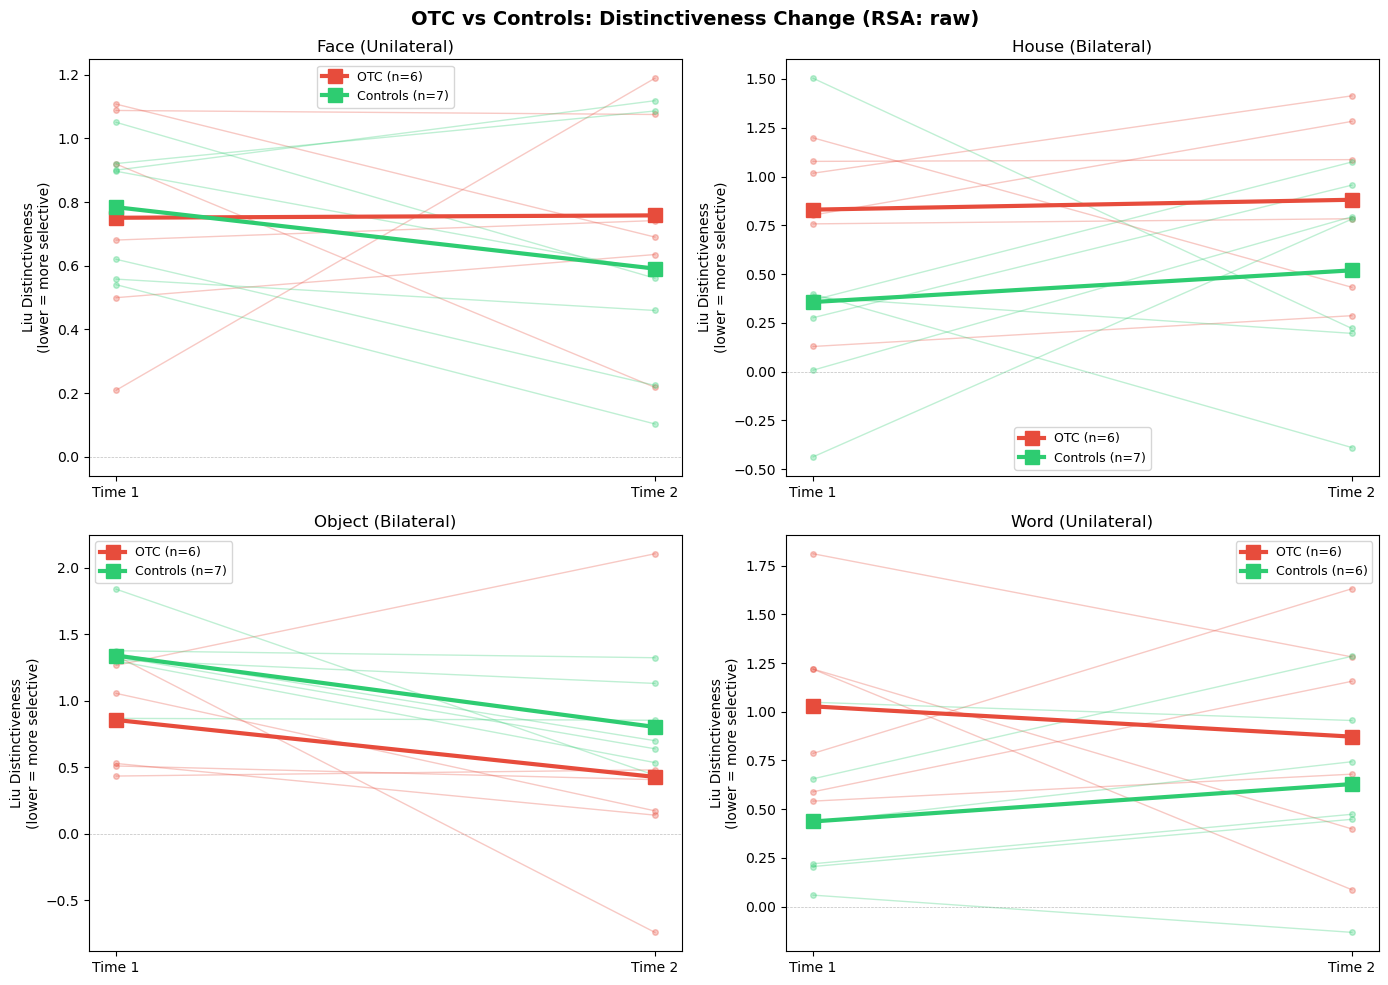

In [59]:
# CELL 6b: Longitudinal Trajectory Plot — OTC vs Controls
###############################################################################

import matplotlib.pyplot as plt

categories = ['face', 'house', 'object', 'word']
groups_plot = {'OTC': '#e74c3c', 'Controls': '#2ecc71'}
drop_nums = {s.replace('sub-', '') for s in AGE_MATCH_DROP}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for cat_idx, category in enumerate(categories):
    ax = axes[cat_idx // 2][cat_idx % 2]
    cat_type = 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral'

    for group_name, group_filter in [('OTC', 'OTC'), ('Controls', 'control')]:
        t1_vals, t2_vals = [], []

        for subject_id, info in ANALYSIS_SUBJECTS.items():
            sub_clean = subject_id.replace('sub-', '')
            if sub_clean in drop_nums or info['code'] in SUBJECTS_TO_SKIP:
                continue
            if group_filter == 'OTC' and info['group'] != 'OTC':
                continue
            if group_filter == 'control' and info['patient_status'] != 'control':
                continue
            if subject_id not in liu_distinctiveness:
                continue
            if category not in liu_distinctiveness[subject_id]:
                continue

            sessions_data = liu_distinctiveness[subject_id][category]
            session_keys = sorted(sessions_data.keys())
            if len(session_keys) < 2:
                continue

            s1, s2 = session_keys[0], session_keys[1]
            y1 = sessions_data[s1]['liu_distinctiveness']
            y2 = sessions_data[s2]['liu_distinctiveness']

            ax.plot([0, 1], [y1, y2], '-o',
                    color=groups_plot[group_name], alpha=0.3, markersize=4, linewidth=1)
            t1_vals.append(y1)
            t2_vals.append(y2)

        if t1_vals:
            ax.plot([0, 1], [np.mean(t1_vals), np.mean(t2_vals)], '-s',
                    color=groups_plot[group_name], linewidth=3, markersize=10,
                    label=f'{group_name} (n={len(t1_vals)})', zorder=10)

    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(f'{category.title()} ({cat_type})')
    ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Time 1', 'Time 2'])
    ax.legend(fontsize=9)

plt.suptitle(f'OTC vs Controls: Distinctiveness Change (RSA: {RSA_METHOD})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f'otc_vs_controls_t1t2_{RSA_METHOD}.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [60]:
# CELL 7: Cross-Sectional Analysis — OTC vs Controls  (CLEANED)
###############################################################################

def analyze_cross_sectional(liu_distinctiveness, analysis_subjects,
                           controls_left_distinctiveness=None):
    """
    Cross-sectional: compare first post-surgical baseline distinctiveness.
    OTC vs Controls only.
    """
    print('CROSS-SECTIONAL ANALYSIS: OTC vs Controls')
    print('=' * 70)
    print(f'RSA Method: {RSA_METHOD}')
    print(f'Hemisphere selection: {PREFERRED_HEMI}')

    rows = []
    drop_nums = {s.replace('sub-', '') for s in AGE_MATCH_DROP}

    for subject_id, info in analysis_subjects.items():
        sub_clean = subject_id.replace('sub-', '')
        code = info['code']
        if code in SUBJECTS_TO_SKIP or sub_clean in drop_nums:
            continue

        group = info['group'] if info['patient_status'] == 'patient' else 'control'

        # Skip nonOTC
        if group == 'nonOTC':
            continue

        post_sessions = get_post_surgery_sessions(subject_id, info['sessions'])
        if not post_sessions:
            continue
        target_session = post_sessions[0]

        # Patients: intact hemisphere
        if info['patient_status'] == 'patient':
            if subject_id not in liu_distinctiveness:
                continue
            for category in ['face', 'house', 'object', 'word']:
                if category not in liu_distinctiveness[subject_id]:
                    continue
                if target_session not in liu_distinctiveness[subject_id][category]:
                    continue
                val = liu_distinctiveness[subject_id][category][target_session]['liu_distinctiveness']
                rows.append({
                    'Subject': code, 'Group': group,
                    'Category': category.title(),
                    'Category_Type': ('Bilateral' if category in BILATERAL_CATEGORIES
                                      else 'Unilateral'),
                    'Hemisphere': info['hemi'],
                    'Distinctiveness': val, 'Session': target_session
                })

        # Controls: both hemispheres
        elif info['patient_status'] == 'control':
            for hemi_label, dsrc in [
                ('r', liu_distinctiveness.get(subject_id, {})),
                ('l', (controls_left_distinctiveness.get(subject_id, {})
                       if controls_left_distinctiveness else {}))
            ]:
                for category in ['face', 'house', 'object', 'word']:
                    if category not in dsrc:
                        continue
                    if target_session not in dsrc[category]:
                        continue
                    val = dsrc[category][target_session]['liu_distinctiveness']
                    rows.append({
                        'Subject': code, 'Group': group,
                        'Category': category.title(),
                        'Category_Type': ('Bilateral' if category in BILATERAL_CATEGORIES
                                          else 'Unilateral'),
                        'Hemisphere': hemi_label,
                        'Distinctiveness': val, 'Session': target_session
                    })

    cross_df = pd.DataFrame(rows)
    if len(cross_df) == 0:
        print("No cross-sectional data.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # Controls: preferred hemisphere, average bilateral
    ctrl = cross_df[cross_df['Group'] == 'control'].copy()
    pref_rows = [row for _, row in ctrl.iterrows()
                 if PREFERRED_HEMI[row['Category']] in ('both', row['Hemisphere'])]
    ctrl_pref = pd.DataFrame(pref_rows)
    ctrl_pref['Subject_Base'] = ctrl_pref['Subject']
    ctrl_avg = ctrl_pref.groupby(
        ['Subject_Base', 'Category', 'Category_Type', 'Group']
    ).agg({'Distinctiveness': 'mean'}).reset_index()

    patient_data = cross_df[cross_df['Group'] != 'control']

    n_otc = patient_data['Subject'].nunique()
    n_ctrl = ctrl_avg['Subject_Base'].nunique()
    print(f"\nSubjects: OTC={n_otc}, Controls={n_ctrl}")

    # Group means
    print(f"\nBASELINE DISTINCTIVENESS (lower = more selective):")
    print(f"{'Group':<12} {'N':<5} {'Bilateral':<14} {'Unilateral':<14} {'Diff':<12}")
    print('-' * 58)

    for gname, data, scol in [('OTC', patient_data, 'Subject'),
                               ('Controls', ctrl_avg, 'Subject_Base')]:
        bil = data[data['Category_Type'] == 'Bilateral']['Distinctiveness']
        uni = data[data['Category_Type'] == 'Unilateral']['Distinctiveness']
        n = data[scol].nunique()
        bm = bil.mean() if len(bil) > 0 else float('nan')
        um = uni.mean() if len(uni) > 0 else float('nan')
        print(f'{gname:<12} {n:<5} {bm:<14.3f} {um:<14.3f} {bm - um:<12.3f}')

    # Per-category
    print(f"\nPER-CATEGORY BASELINE:")
    print(f"{'Group':<12} {'Cat':<10} {'N':<5} {'Mean':<10} {'SD':<10}")
    print('-' * 50)
    for gname, data in [('OTC', patient_data), ('Controls', ctrl_avg)]:
        for cat in ['Face', 'House', 'Object', 'Word']:
            vals = data[data['Category'] == cat]['Distinctiveness']
            if len(vals) == 0:
                continue
            print(f'{gname:<12} {cat:<10} {len(vals):<5} {vals.mean():<10.3f} {vals.std():<10.3f}')

    # Stats
    print(f"\nSTATISTICAL TESTS:")
    print('-' * 50)
    for cat_type in ['Bilateral', 'Unilateral']:
        otc_v = patient_data[patient_data['Category_Type'] == cat_type]['Distinctiveness'].values
        ctrl_v = ctrl_avg[ctrl_avg['Category_Type'] == cat_type]['Distinctiveness'].values
        if len(otc_v) > 2 and len(ctrl_v) > 2:
            t, p = ttest_ind(otc_v, ctrl_v)
            u, pu = mannwhitneyu(otc_v, ctrl_v, alternative='two-sided')
            print(f"  {cat_type}: OTC({otc_v.mean():.3f}) vs Ctrl({ctrl_v.mean():.3f}) "
                  f"t={t:.2f} p={p:.3f} | U={u:.0f} p={pu:.3f}")

    return cross_df, ctrl_avg, patient_data


cross_df, ctrl_cross, patient_cross = analyze_cross_sectional(
    liu_distinctiveness, ANALYSIS_SUBJECTS, controls_left_distinctiveness
)
print('\nCross-sectional complete!')

CROSS-SECTIONAL ANALYSIS: OTC vs Controls
RSA Method: raw
Hemisphere selection: {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

Subjects: OTC=9, Controls=12

BASELINE DISTINCTIVENESS (lower = more selective):
Group        N     Bilateral      Unilateral     Diff        
----------------------------------------------------------
OTC          9     0.730          0.845          -0.115      
Controls     12    0.790          0.704          0.086       

PER-CATEGORY BASELINE:
Group        Cat        N     Mean       SD        
--------------------------------------------------
OTC          Face       8     0.764      0.302     
OTC          House      9     0.731      0.567     
OTC          Object     9     0.728      0.397     
OTC          Word       8     0.925      0.522     
Controls     Face       12    0.712      0.218     
Controls     House      12    0.435      0.366     
Controls     Object     12    1.145      0.385     
Controls     Word       12    0.695     

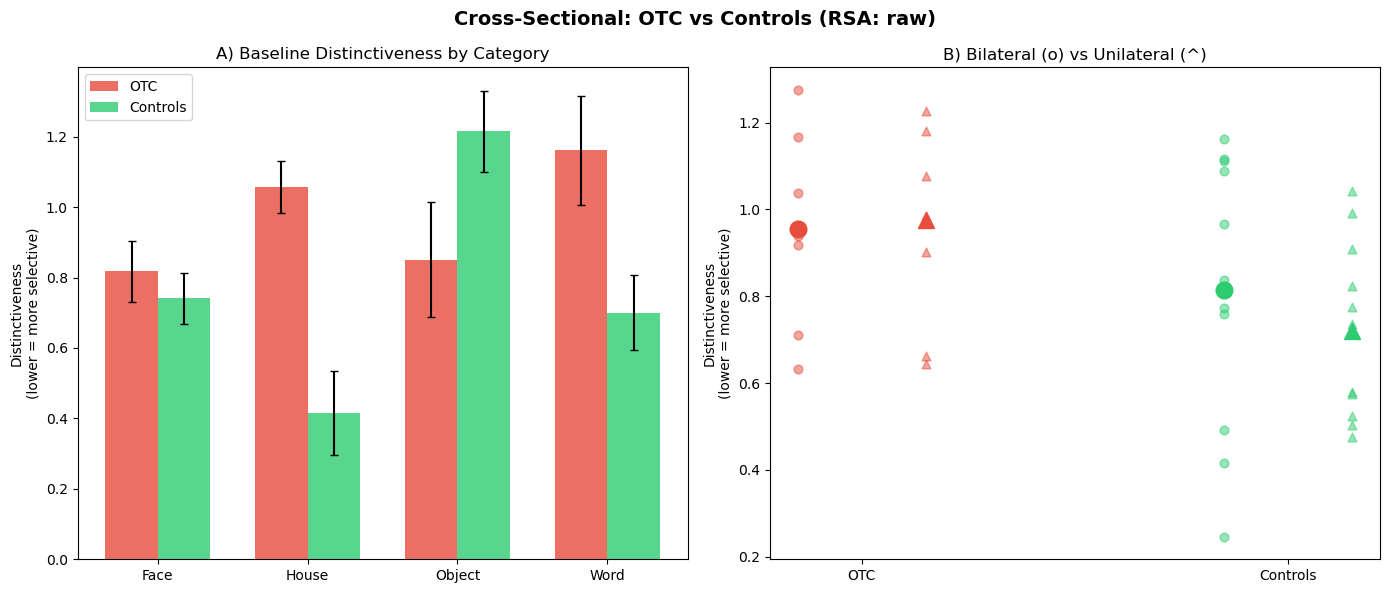

In [46]:
# CELL 8: Cross-Sectional Visualization — OTC vs Controls  (CLEANED)
###############################################################################

def plot_cross_sectional(patient_data, ctrl_avg):
    """Bar + scatter for OTC vs Controls cross-sectional."""

    categories = ['Face', 'House', 'Object', 'Word']
    groups = ['OTC', 'control']
    colors = {'OTC': '#e74c3c', 'control': '#2ecc71'}
    labels = {'OTC': 'OTC', 'control': 'Controls'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A: by category
    ax = axes[0]
    x = np.arange(len(categories))
    width = 0.35
    for i, group in enumerate(groups):
        data = ctrl_avg if group == 'control' else patient_data
        means, sems = [], []
        for cat in categories:
            vals = data[data['Category'] == cat]['Distinctiveness']
            means.append(vals.mean() if len(vals) > 0 else 0)
            sems.append(vals.std() / np.sqrt(len(vals)) if len(vals) > 1 else 0)
        ax.bar(x + i * width, means, width, yerr=sems,
               label=labels[group], color=colors[group], alpha=0.8, capsize=3)
    ax.set_ylabel('Distinctiveness\n(lower = more selective)')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.set_title('A) Baseline Distinctiveness by Category')

    # Panel B: bilateral vs unilateral
    ax = axes[1]
    for i, group in enumerate(groups):
        data = ctrl_avg if group == 'control' else patient_data
        subj_col = 'Subject_Base' if group == 'control' else 'Subject'
        if len(data) == 0:
            continue
        for subj in data[subj_col].unique():
            sd = data[data[subj_col] == subj]
            bil = sd[sd['Category_Type'] == 'Bilateral']['Distinctiveness'].mean()
            uni = sd[sd['Category_Type'] == 'Unilateral']['Distinctiveness'].mean()
            ax.scatter(i, bil, color=colors[group], marker='o', alpha=0.5, s=40)
            ax.scatter(i + 0.3, uni, color=colors[group], marker='^', alpha=0.5, s=40)
        bil_m = data[data['Category_Type'] == 'Bilateral']['Distinctiveness'].mean()
        uni_m = data[data['Category_Type'] == 'Unilateral']['Distinctiveness'].mean()
        ax.plot([i], [bil_m], 'o', color=colors[group], markersize=12, zorder=10)
        ax.plot([i + 0.3], [uni_m], '^', color=colors[group], markersize=12, zorder=10)
    ax.set_xticks([0.15, 1.15])
    ax.set_xticklabels(['OTC', 'Controls'])
    ax.set_ylabel('Distinctiveness\n(lower = more selective)')
    ax.set_title('B) Bilateral (o) vs Unilateral (^)')

    plt.suptitle(f'Cross-Sectional: OTC vs Controls (RSA: {RSA_METHOD})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'cross_sectional_{RSA_METHOD}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


if len(patient_cross) > 0:
    plot_cross_sectional(patient_cross, ctrl_cross)

In [47]:
# CELL 9: Verification
###############################################################################

print('=' * 70)
print('VERIFICATION')
print('=' * 70)
print(f'\n1. RSA: {RSA_METHOD} → {ACTIVE_RSA_MAP}')
print(f'2. Comparison: OTC vs Controls (nonOTC excluded from group analyses)')
print(f'3. Total rows: {len(results_table)}')
if len(results_table) > 0:
    print(f'   Unique subjects: {results_table["Subject"].nunique()}')
    print(f'   Columns: {list(results_table.columns)}')
    for g in ['OTC', 'nonOTC']:
        n = len(results_table[results_table['Group'] == g])
        print(f'   {g}: {n} rows')
    n_ctrl = len(results_table[results_table['Status'] == 'control'])
    print(f'   Controls: {n_ctrl} rows')
print(f'4. Params: 6mm sphere, z>2.3, min 50 vox')
print(f'5. Age-matched drops: {AGE_MATCH_DROP}')
print(f'6. Pre-surgery exclusions: {list(PRE_SURGERY_SESSIONS.keys())}')

VERIFICATION

1. RSA: raw → {'face': 15, 'house': 16, 'object': 17, 'word': 18}
2. Comparison: OTC vs Controls (nonOTC excluded from group analyses)
3. Total rows: 125
   Unique subjects: 33
   Columns: ['Subject', 'Group', 'Status', 'Hemisphere', 'Category', 'Category_Type', 'Spatial_Drift_mm', 'Abs_Change', 'Signed_Change', 'Baseline_Distinct', 'Final_Distinct', 'Sessions']
   OTC: 24 rows
   nonOTC: 33 rows
   Controls: 68 rows
4. Params: 6mm sphere, z>2.3, min 50 vox
5. Age-matched drops: ['sub-025', 'sub-027', 'sub-045', 'sub-072']
6. Pre-surgery exclusions: ['sub-021', 'sub-045', 'sub-047', 'sub-049', 'sub-070', 'sub-073', 'sub-081', 'sub-086']
